In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Titanic Survival Prediction - ECE 564 Mini Project

## Project Overview

This project aims to develop a complete machine learning pipeline for predicting passenger survival in the Titanic dataset. The task is a binary classification problem because the target variable, `Survived`, has two possible outcomes: 1 for survived and 0 for not survived.

The project follows an end-to-end machine learning workflow including exploratory data analysis, data preprocessing, feature engineering, model development, validation, dimensionality reduction, feature selection, hyperparameter optimization, model ensembling, research-based improvements, and final Kaggle submission.

The main goal is not only to obtain a high Kaggle leaderboard score, but also to build a reproducible, well-explained, and logically justified machine learning pipeline.

In [11]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

# Basic data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing tools
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC

# Dimensionality reduction and feature selection
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Ignore warnings for cleaner notebook output
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
# ============================================================
# 2. Load Titanic Dataset
# ============================================================

# File paths in Kaggle environment
train_path = "/kaggle/input/competitions/titanic/train.csv"
test_path = "/kaggle/input/competitions/titanic/test.csv"
gender_submission_path = "/kaggle/input/competitions/titanic/gender_submission.csv"

# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
gender_submission = pd.read_csv(gender_submission_path)

# Display shapes
print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("Sample submission shape:", gender_submission.shape)

# Show first 5 rows of training data
train_df.head()

Training dataset shape: (891, 12)
Test dataset shape: (418, 11)
Sample submission shape: (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Description

The Titanic dataset contains passenger-level information such as passenger class, sex, age, number of siblings/spouses aboard, number of parents/children aboard, ticket information, fare, cabin, and port of embarkation.

The target variable is `Survived`.

- `Survived = 1`: The passenger survived.
- `Survived = 0`: The passenger did not survive.

Since the target variable has two classes, this is a binary classification problem.

In [13]:
# ============================================================
# 3. Basic Data Inspection
# ============================================================

print("First 5 rows of the training dataset:")
display(train_df.head())

print("\nLast 5 rows of the training dataset:")
display(train_df.tail())

print("\nDataset information:")
train_df.info()

print("\nSummary statistics for numeric features:")
display(train_df.describe())

print("\nSummary statistics for categorical features:")
display(train_df.describe(include="object"))

First 5 rows of the training dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Last 5 rows of the training dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Summary statistics for numeric features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Summary statistics for categorical features:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [14]:
print("TRAIN DATA SHAPE")
print(train_df.shape)

print("\nTEST DATA SHAPE")
print(test_df.shape)


print("\n" + "="*50)
print("TRAIN DATA INFO")
print("="*50)
train_df.info()

TRAIN DATA SHAPE
(891, 12)

TEST DATA SHAPE
(418, 11)

TRAIN DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
# ============================================================
# 4. Missing Value Analysis
# ============================================================

missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values in training dataset:")
display(missing_values)

missing_percentage = (missing_values / len(train_df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage (%)": missing_percentage.round(2)
})

display(missing_table)

Missing values in training dataset:


Cabin       687
Age         177
Embarked      2
dtype: int64

,Missing Count,Missing Percentage (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## Missing Value Analysis

The missing value analysis shows that the training dataset contains missing values in three features: `Cabin`, `Age`, and `Embarked`.

The number and percentage of missing values are:

- `Cabin`: 687 missing values, which corresponds to 77.10% of the training dataset.
- `Age`: 177 missing values, which corresponds to 19.87% of the training dataset.
- `Embarked`: 2 missing values, which corresponds to 0.22% of the training dataset.

Among these features, `Cabin` has the highest missing value ratio. Since more than three-quarters of the values are missing, using the raw `Cabin` variable directly may not be reliable. However, instead of completely ignoring this information, a new feature such as `HasCabin` or `Deck` can be engineered from the available cabin records.

The `Age` feature also contains a considerable number of missing values. Since `Age` is a numerical feature, the missing values will be handled using median imputation. Median imputation is preferred because it is more robust to outliers than mean imputation.

The `Embarked` feature has only 2 missing values. Since it is a categorical feature and the missing value ratio is very low, these missing values will be filled using the most frequent category.

In summary, the missing value handling strategy will be:

- Fill missing `Age` values using the median.
- Fill missing `Embarked` values using the most frequent category.
- Use `Cabin` carefully by engineering new features instead of directly using the raw cabin values.

In [16]:
# ============================================================
# 5. Feature Type Identification
# ============================================================

feature_types = pd.DataFrame({
    "Feature": train_df.columns,
    "Data Type": train_df.dtypes.values,
    "Example Value": train_df.iloc[0].values
})

display(feature_types)

,Feature,Data Type,Example Value
0,PassengerId,int64,1
1,Survived,int64,0
2,Pclass,int64,3
3,Name,object,"Braund, Mr. Owen Harris"
4,Sex,object,male
5,Age,float64,22.0
6,SibSp,int64,1
7,Parch,int64,0
8,Ticket,object,A/5 21171
9,Fare,float64,7.25


## Feature Type Identification

The Titanic dataset contains different types of features, including identifier, target, numerical, categorical, ordinal, and text-based variables. Identifying the feature types is important because each type requires a different preprocessing strategy before model training.

The feature types are summarized as follows:

- `PassengerId`: Identifier variable. It gives a unique ID for each passenger. It is not useful for model learning, but it will be needed later when creating the Kaggle submission file.

- `Survived`: Target variable. It is a binary categorical variable where `1` means the passenger survived and `0` means the passenger did not survive.

- `Pclass`: Ordinal categorical variable. It represents the passenger ticket class. Although it is stored as an integer, it has an order: 1st class, 2nd class, and 3rd class.

- `Name`: Text-based variable. The full passenger name is not directly suitable for model training, but useful information such as social title can be extracted from it. For example, titles such as `Mr`, `Mrs`, `Miss`, and `Master` may provide information related to age, gender, or social status.

- `Sex`: Nominal categorical variable. It represents the passenger's gender and must be encoded into numeric form before model training.

- `Age`: Numerical continuous variable. It represents the passenger's age. Since this feature contains missing values, it needs imputation before training the models.

- `SibSp`: Numerical discrete variable. It represents the number of siblings or spouses the passenger had aboard the Titanic.

- `Parch`: Numerical discrete variable. It represents the number of parents or children the passenger had aboard the Titanic.

- `Ticket`: Text-based categorical variable. It represents the ticket number. The raw ticket value may not be directly informative, but ticket-related patterns or group information may be useful for feature engineering.

- `Fare`: Numerical continuous variable. It represents the ticket fare paid by the passenger. Since fare values may be skewed, a transformation such as log transformation can be considered.

- `Cabin`: Text-based categorical variable. It represents cabin information. Since it has many missing values, the raw cabin variable may not be reliable. However, a new feature such as `HasCabin` or `Deck` can be created from it.

- `Embarked`: Nominal categorical variable. It represents the port of embarkation and has three main categories: `C`, `Q`, and `S`. It must be encoded before model training.

In summary, numerical features such as `Age`, `SibSp`, `Parch`, and `Fare` will be handled with numerical preprocessing methods. Categorical features such as `Sex`, `Embarked`, and engineered features from `Name` or `Cabin` will be encoded into numerical format. Identifier and raw text features such as `PassengerId`, `Name`, `Ticket`, and `Cabin` will either be dropped or transformed into more informative engineered features.

## Exploratory Data Analysis Continued

After checking the general structure of the dataset, missing values, feature types, and summary statistics, the next step is to visualize the data. Visualization helps us understand the distribution of numerical variables, the relationship between input features and the target variable, and the correlation structure among features.

In this section, histogram plots, target-based comparison plots, and a correlation heatmap are generated.

Numeric features:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


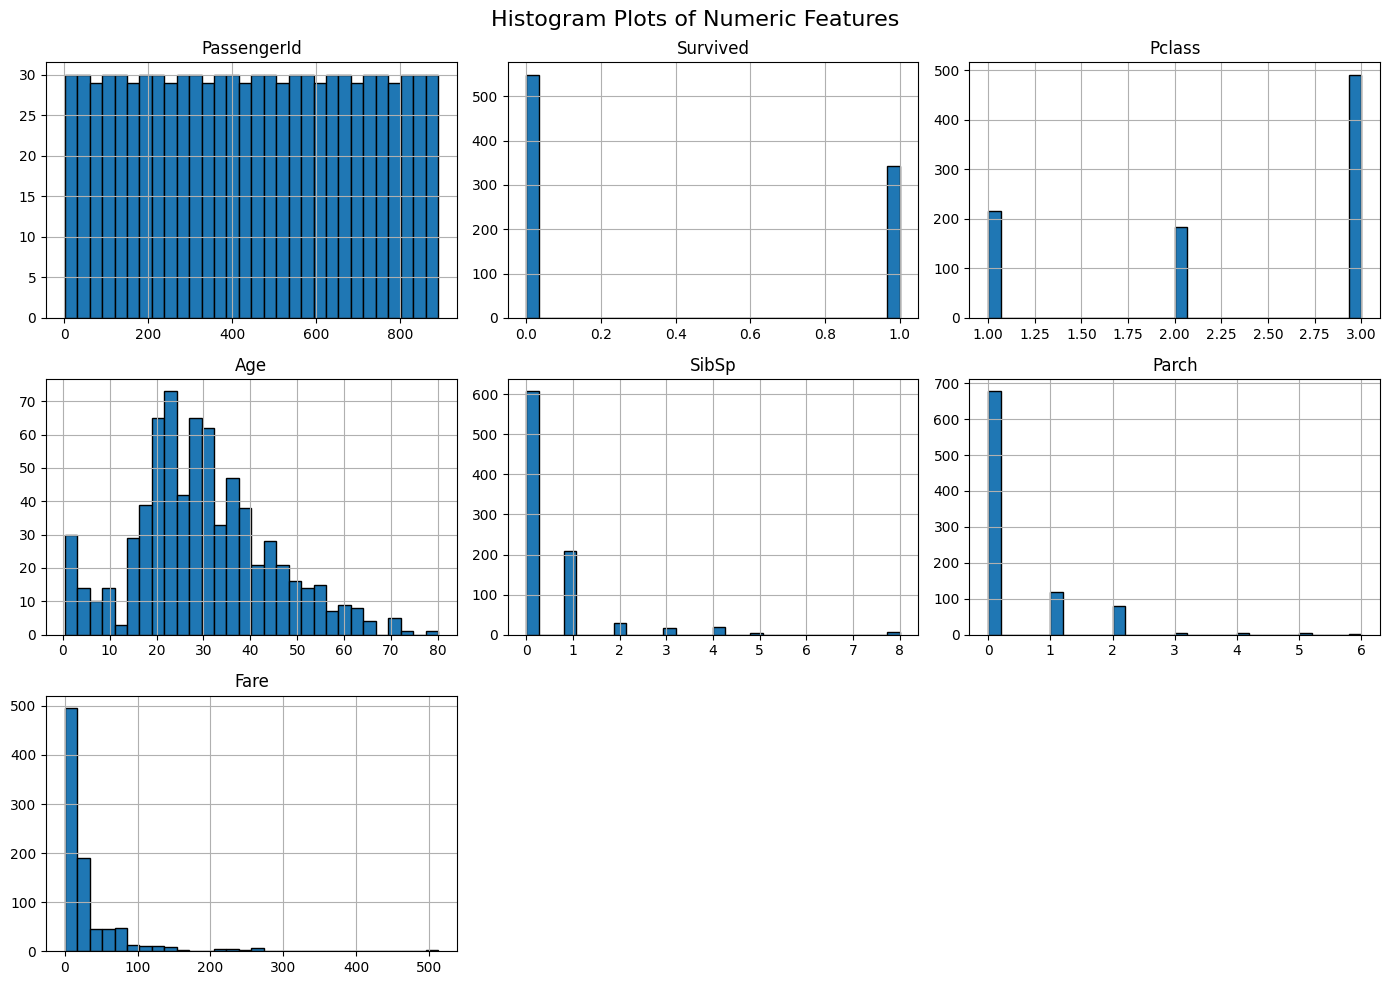

In [17]:
# ============================================================
# 6. Histogram Plots for Numeric Features
# ============================================================

numeric_features = train_df.select_dtypes(include=["int64", "float64"]).columns

print("Numeric features:")
print(list(numeric_features))

train_df[numeric_features].hist(
    bins=30,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Histogram Plots of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

## Histogram Analysis of Numeric Features

The histogram plots show the distributions of the numerical features in the Titanic training dataset. These plots help us understand the general structure of the data, detect skewed variables, and identify which features may require transformation before model training.

`PassengerId` has an almost uniform distribution because it is only an identification number assigned to each passenger. Since it does not represent a meaningful passenger characteristic, it will not be used as an input feature for model training.

`Survived` is the target variable and has a binary distribution. The histogram shows that the number of passengers who did not survive is higher than the number of passengers who survived. This indicates that the dataset is not perfectly balanced, although the imbalance is not extremely severe.

`Pclass` is stored as a numerical variable, but it actually represents an ordinal categorical feature. The histogram shows that most passengers belong to the 3rd class, while fewer passengers are in the 1st and 2nd classes. This feature may be important because passenger class can be related to socio-economic status and survival probability.

`Age` is a continuous numerical feature. The distribution shows that most passengers are young or middle-aged adults, especially between approximately 20 and 40 years old. There are also some children and elderly passengers in the dataset. Since `Age` contains missing values, these values should be handled during preprocessing.

`SibSp` is a discrete numerical feature that represents the number of siblings or spouses aboard. The histogram shows that most passengers had 0 or 1 sibling/spouse aboard. Higher values are rare.

`Parch` is also a discrete numerical feature and represents the number of parents or children aboard. Most passengers had 0 parents or children aboard, meaning that many passengers traveled without immediate family members recorded in this feature.

`Fare` is a continuous numerical feature and has a highly right-skewed distribution. Most passengers paid relatively low fares, while a small number of passengers paid very high fares. Because of this skewness, applying a log transformation such as `log1p(Fare)` can be useful before model training.

Overall, the histogram analysis shows that `Fare` is strongly skewed, `Age` has missing values, and family-related variables such as `SibSp` and `Parch` are concentrated mostly around low values. These observations will guide the preprocessing and feature engineering steps.

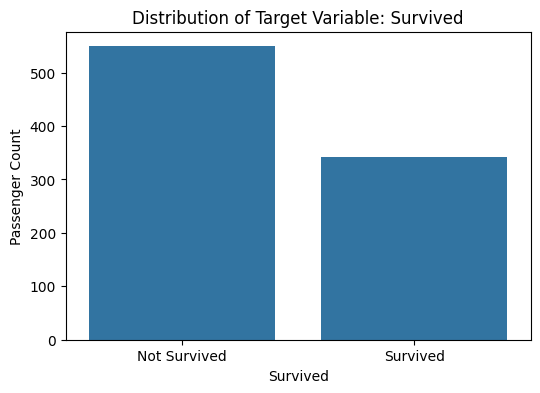

,Count,Percentage (%)
Survived,,
0,549,61.62
1,342,38.38


In [18]:
# ============================================================
# 7. Target Variable Distribution
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="Survived")
plt.title("Distribution of Target Variable: Survived")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

survival_counts = train_df["Survived"].value_counts()
survival_percentages = train_df["Survived"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "Count": survival_counts,
    "Percentage (%)": survival_percentages.round(2)
})

display(target_distribution)

## Target Variable Distribution

The target variable `Survived` shows whether a passenger survived or did not survive. According to the output, 549 passengers did not survive, while 342 passengers survived.

In percentage terms:

- `Survived = 0`: 549 passengers, corresponding to 61.62% of the training dataset.
- `Survived = 1`: 342 passengers, corresponding to 38.38% of the training dataset.

This result shows that the dataset is not perfectly balanced. The number of passengers who did not survive is higher than the number of passengers who survived. However, the imbalance is not extremely severe, so accuracy can still be used as an important metric.

Since the target classes are moderately imbalanced, accuracy alone may not fully explain model performance. Therefore, in the final model evaluation, additional metrics such as precision, recall, F1-score, balanced accuracy, AUROC, and AUPRC should also be reported.

This distribution also gives an important baseline. If a model always predicted the majority class, which is `Not Survived`, it would achieve approximately 61.62% accuracy. Therefore, the machine learning models should achieve a clearly higher score than this baseline to be considered useful.

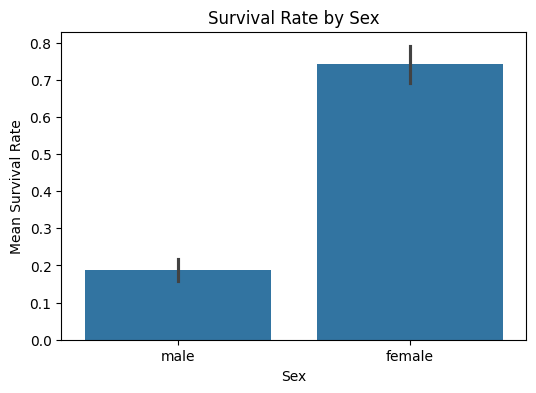

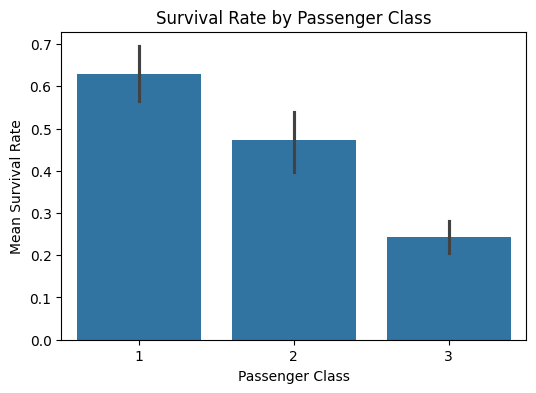

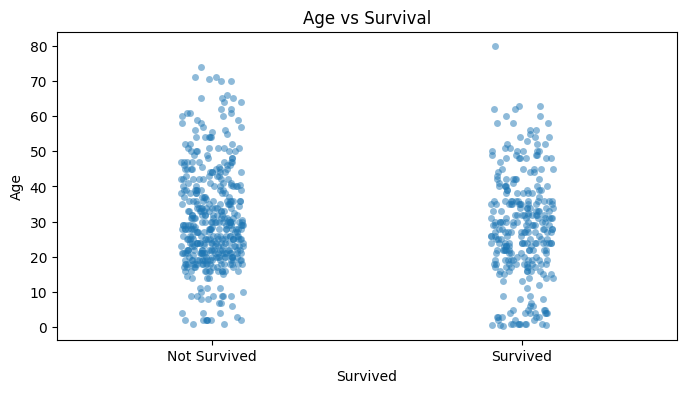

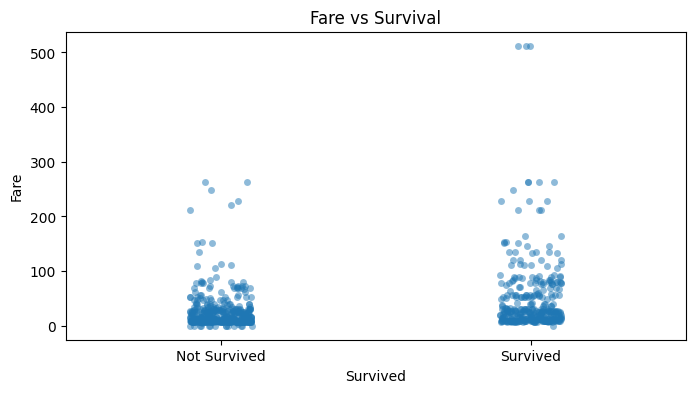

In [19]:
# ============================================================
# 8. Relationship Between Input Features and Survival
# ============================================================

# Survival rate by Sex
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Mean Survival Rate")
plt.show()

# Survival rate by Pclass
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Mean Survival Rate")
plt.show()

# Age vs Survival scatter/strip plot
plt.figure(figsize=(8, 4))
sns.stripplot(data=train_df, x="Survived", y="Age", jitter=True, alpha=0.5)
plt.title("Age vs Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

# Fare vs Survival scatter/strip plot
plt.figure(figsize=(8, 4))
sns.stripplot(data=train_df, x="Survived", y="Fare", jitter=True, alpha=0.5)
plt.title("Fare vs Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

## Relationship Between Input Features and Survival

The plots above show the relationship between selected input features and the target variable `Survived`. This step is important because it helps identify which variables may be useful for predicting passenger survival.

The first plot shows the survival rate by `Sex`. Female passengers have a much higher survival rate than male passengers. The mean survival rate of female passengers is around 0.74, while the mean survival rate of male passengers is around 0.19. This indicates that `Sex` is one of the strongest predictors of survival in the Titanic dataset.

The second plot shows the survival rate by `Pclass`. The survival rate is highest for 1st class passengers, lower for 2nd class passengers, and lowest for 3rd class passengers. This suggests that passenger class is strongly related to survival probability. Since lower `Pclass` values represent higher socio-economic class, this feature is expected to be important for model training.

The `Age vs Survival` plot shows that both survived and non-survived groups contain passengers from different age ranges. However, younger passengers, especially children, appear more frequently among survivors compared with older passenger groups. The relationship between `Age` and survival is not as clear as `Sex` or `Pclass`, but it may still provide useful information when combined with other features.

The `Fare vs Survival` plot shows that passengers who paid higher fares appear more frequently in the survived group. There are also some high-fare outliers, especially among survived passengers. This suggests that `Fare` may be related to survival, probably because higher fares are associated with higher passenger classes.

Overall, the visual analysis indicates that `Sex`, `Pclass`, and `Fare` have strong relationships with survival. `Age` may also contribute to prediction, especially when combined with engineered features such as passenger title or age groups.

In [20]:
# ============================================================
# 9. Survival Rate Tables for Important Categorical Features
# ============================================================

print("Survival rate by Sex:")
display(train_df.groupby("Sex")["Survived"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("Survival rate by Pclass:")
display(train_df.groupby("Pclass")["Survived"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

print("Survival rate by Embarked:")
display(train_df.groupby("Embarked")["Survived"].agg(["count", "mean"]).sort_values(by="mean", ascending=False))

Survival rate by Sex:


,count,mean
Sex,,
female,314,0.742038
male,577,0.188908


Survival rate by Pclass:


,count,mean
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


Survival rate by Embarked:


,count,mean
Embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957


## Survival Rate Analysis by Categorical Features

The grouped survival rate tables provide numerical evidence for the relationship between categorical input features and the target variable `Survived`.

For the `Sex` feature, female passengers have a much higher survival rate than male passengers. There are 314 female passengers in the training dataset, and their mean survival rate is approximately 0.7420. This means that about 74.20% of female passengers survived. On the other hand, there are 577 male passengers, and their mean survival rate is approximately 0.1889, meaning that only about 18.89% of male passengers survived. This large difference shows that `Sex` is one of the strongest predictors of survival.

For the `Pclass` feature, survival rate decreases as passenger class number increases. First-class passengers have the highest survival rate, approximately 0.6296. Second-class passengers have a survival rate of approximately 0.4728, while third-class passengers have the lowest survival rate, approximately 0.2424. This indicates that socio-economic status, represented by passenger class, had a strong relationship with survival probability.

For the `Embarked` feature, passengers who embarked from port `C` have the highest survival rate, approximately 0.5536. Passengers from port `Q` have a survival rate of approximately 0.3896, while passengers from port `S` have the lowest survival rate, approximately 0.3370. This suggests that `Embarked` may contain useful information for prediction. However, this relationship may also be affected by other variables such as passenger class, fare, and passenger demographics.

Overall, these results confirm the previous visual findings. `Sex` and `Pclass` show very strong relationships with survival, while `Embarked` also provides potentially useful predictive information. Therefore, these categorical features should be included in the machine learning pipeline after proper encoding.

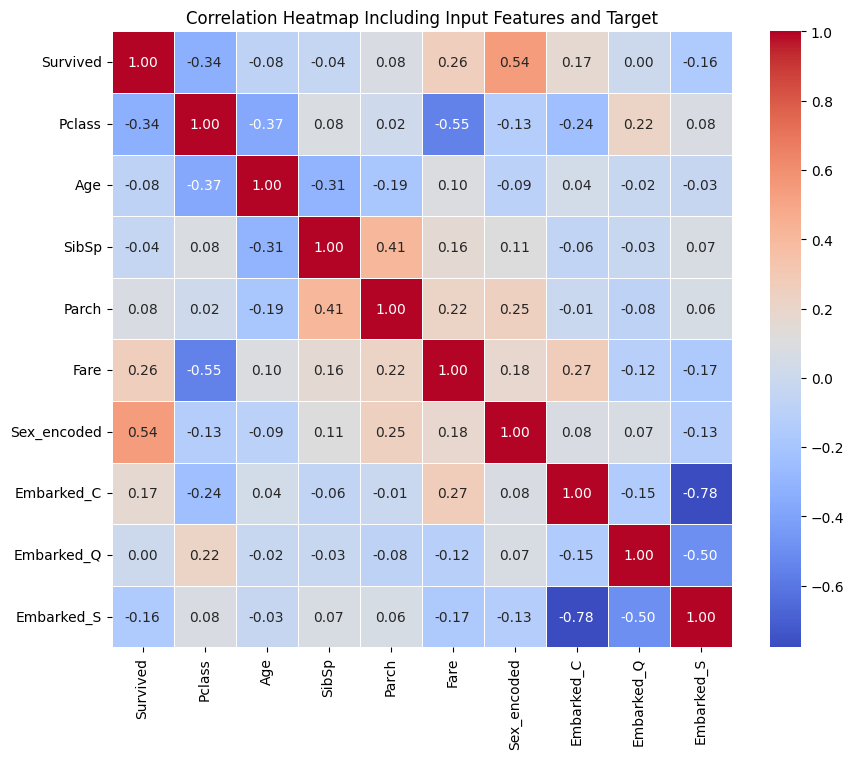

Correlation with Survived:


Survived       1.000000
Sex_encoded    0.543351
Fare           0.257307
Embarked_C     0.168240
Parch          0.081629
Embarked_Q     0.003650
SibSp         -0.035322
Age           -0.077221
Embarked_S    -0.155660
Pclass        -0.338481
Name: Survived, dtype: float64

In [21]:
# ============================================================
# 10. Correlation Heatmap
# ============================================================

# Create a copy for correlation analysis
corr_df = train_df.copy()

# Simple encoding only for correlation analysis
corr_df["Sex_encoded"] = corr_df["Sex"].map({"male": 0, "female": 1})

# Embarked one-hot encoding for correlation analysis
corr_df = pd.get_dummies(corr_df, columns=["Embarked"], drop_first=False)

# Select numeric columns for correlation
corr_features = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex_encoded",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

corr_matrix = corr_df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap Including Input Features and Target")
plt.show()

# Print correlations with target variable
target_correlations = corr_matrix["Survived"].sort_values(ascending=False)
print("Correlation with Survived:")
display(target_correlations)

## Correlation Heatmap Analysis

The correlation heatmap shows the linear relationships between the target variable `Survived` and selected input features. Since correlation values range from -1 to +1, positive values indicate a positive relationship with survival, while negative values indicate a negative relationship.

According to the correlation results, the strongest positive correlation with `Survived` belongs to `Sex_encoded`, with a correlation value of approximately 0.5434. In this encoding, female passengers are represented with 1 and male passengers with 0. Therefore, this positive correlation confirms that female passengers had a much higher probability of survival. This result is consistent with the previous survival rate analysis by sex.

The `Fare` feature has a positive correlation of approximately 0.2573 with survival. This means that passengers who paid higher fares generally had a higher chance of survival. This relationship may also be connected to passenger class, because first-class passengers usually paid higher fares.

The `Embarked_C` feature also has a positive correlation of approximately 0.1682 with survival. This suggests that passengers who embarked from port C had a relatively higher survival rate compared with other embarkation ports. However, this relationship may be influenced by other variables such as passenger class and fare.

The `Pclass` feature has a negative correlation of approximately -0.3385 with survival. Since `Pclass = 1` represents first class and `Pclass = 3` represents third class, this negative correlation means that passengers in higher classes had better survival chances. In other words, as the class number increases from 1 to 3, the survival probability decreases.

The `Embarked_S` feature has a negative correlation of approximately -0.1557 with survival, which means that passengers who embarked from port S had a lower survival tendency compared with some other groups.

The `Age`, `SibSp`, and `Parch` features show weaker correlations with survival. For example, `Age` has a weak negative correlation of approximately -0.0772, while `Parch` has a weak positive correlation of approximately 0.0816. These weak correlations do not necessarily mean that the features are useless. They may still become useful when combined with other variables or when non-linear models such as decision trees, random forests, and gradient boosting models are used.

Overall, the heatmap confirms that the most important linearly related features are `Sex_encoded`, `Pclass`, and `Fare`. Therefore, these variables should be included carefully in the model development stage. In addition, engineered features based on family size, title, cabin information, and transformed fare may further improve prediction performance.

## Summary of EDA Findings

The exploratory data analysis provides several important insights for the Titanic survival prediction task.

First, the dataset contains 891 training instances and 418 test instances. The training dataset has 12 columns, including the target variable `Survived`, while the test dataset has 11 columns because the target variable is not provided. The sample submission file contains 418 rows and 2 columns, which shows that predictions must be generated for all passengers in the test set.

Second, missing values are observed in three features: `Cabin`, `Age`, and `Embarked`. The `Cabin` feature has the highest number of missing values, with 687 missing records corresponding to 77.10% of the training data. The `Age` feature has 177 missing values, corresponding to 19.87% of the dataset. The `Embarked` feature has only 2 missing values, corresponding to 0.22%. Therefore, `Age` and `Embarked` can be handled using imputation, while `Cabin` should not be used directly because of its very high missing value ratio. Instead, more meaningful features such as `HasCabin` or `Deck` can be engineered from it.

Third, the target variable distribution shows that 549 passengers did not survive, while 342 passengers survived. This means that 61.62% of the passengers belong to the `Not Survived` class and 38.38% belong to the `Survived` class. The dataset is therefore moderately imbalanced. A simple majority-class prediction would already achieve approximately 61.62% accuracy, so the developed machine learning models should perform clearly better than this baseline.

Fourth, the summary statistics show that the average passenger age is approximately 29.70 years, while the median age is 28 years. Most passengers are young or middle-aged adults. The `Fare` feature has a highly right-skewed distribution because most passengers paid relatively low fares, while a small number of passengers paid very high fares. For this reason, a log transformation can be useful for reducing skewness in the fare distribution.

Fifth, the visual analysis shows that `Sex`, `Pclass`, and `Fare` are strongly related to survival. Female passengers have a much higher survival rate than male passengers. Specifically, the survival rate is approximately 74.20% for female passengers and 18.89% for male passengers. Passenger class also shows a clear pattern: first-class passengers have the highest survival rate at approximately 62.96%, second-class passengers have a survival rate of approximately 47.28%, and third-class passengers have the lowest survival rate at approximately 24.24%. This indicates that socio-economic status, represented by passenger class, is an important factor in survival prediction.

Sixth, the `Embarked` feature also shows variation in survival rates. Passengers who embarked from port `C` have the highest survival rate at approximately 55.36%, followed by passengers from port `Q` with approximately 38.96%, and passengers from port `S` with approximately 33.70%. However, this relationship may also be affected by other variables such as passenger class and fare.

Finally, the correlation heatmap supports these findings. The strongest positive correlation with `Survived` is observed for `Sex_encoded`, with a correlation value of approximately 0.5434. The `Fare` feature also has a positive correlation with survival, approximately 0.2573. On the other hand, `Pclass` has a negative correlation of approximately -0.3385, meaning that passengers in higher classes had better survival chances because lower class numbers represent higher passenger classes. The heatmap also shows that `Age`, `SibSp`, and `Parch` have weaker linear correlations with survival, but they may still be useful when combined with engineered features or non-linear models.

Overall, the EDA results suggest that `Sex`, `Pclass`, `Fare`, and `Embarked` are important features for survival prediction. In addition, feature engineering based on `Name`, `Cabin`, and family-related variables may improve model performance. Therefore, the next step is to build a clean preprocessing and feature engineering pipeline before training machine learning models.

# Data Preprocessing and Feature Engineering

In this section, a clean preprocessing methodology is implemented before model training. The goal is to handle missing values, remove uninformative raw features, encode categorical variables, transform skewed numerical features, scale numerical features when necessary, and create new informative features.

Feature engineering is especially important for the Titanic dataset because variables such as passenger title, family size, cabin availability, and fare per person can provide additional predictive information.

In [22]:
# ============================================================
# 11. Feature Engineering Function
# ============================================================

def engineer_features(df):
    """
    This function creates new features from the original Titanic dataset.
    The same function will be applied to both training and test datasets
    to keep preprocessing consistent and reproducible.
    """
    
    df = df.copy()
    
    # ------------------------------------------------------------
    # 1. FamilySize: total number of family members aboard
    # ------------------------------------------------------------
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    
    # ------------------------------------------------------------
    # 2. IsAlone: whether the passenger traveled alone
    # ------------------------------------------------------------
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    
    # ------------------------------------------------------------
    # 3. Title: extract title from passenger name
    # Example: "Braund, Mr. Owen Harris" -> "Mr"
    # ------------------------------------------------------------
    df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\\.", expand=False)
    
    # Group rare titles into a single category
    rare_titles = [
        "Lady", "Countess", "Capt", "Col", "Don", "Dr",
        "Major", "Rev", "Sir", "Jonkheer", "Dona"
    ]
    
    df["Title"] = df["Title"].replace(rare_titles, "Rare")
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })
    
    # ------------------------------------------------------------
    # 4. HasCabin: whether cabin information is available
    # ------------------------------------------------------------
    df["HasCabin"] = df["Cabin"].notnull().astype(int)
    
    # ------------------------------------------------------------
    # 5. Deck: first letter of cabin, missing values as "Unknown"
    # ------------------------------------------------------------
    df["Deck"] = df["Cabin"].astype(str).str[0]
    df["Deck"] = df["Deck"].replace("n", "Unknown")
    
    # ------------------------------------------------------------
    # 6. FarePerPerson: fare divided by family size
    # ------------------------------------------------------------
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]
    
    # ------------------------------------------------------------
    # 7. LogFare: log transformation for skewed Fare variable
    # np.log1p is used because Fare may include zero values
    # ------------------------------------------------------------
    df["LogFare"] = np.log1p(df["Fare"])
    
    return df


# Apply feature engineering to both train and test datasets
train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

print("Training data after feature engineering:", train_fe.shape)
print("Test data after feature engineering:", test_fe.shape)

train_fe.head()

Training data after feature engineering: (891, 19)
Test data after feature engineering: (418, 18)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title,HasCabin,Deck,FarePerPerson,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr,0,Unknown,3.62500,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs,1,C,35.64165,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss,0,Unknown,7.92500,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs,1,C,26.55000,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr,0,Unknown,8.05000,2.202765


## Feature Engineering Results

After applying the feature engineering function, the training dataset increased from 12 columns to 19 columns, and the test dataset increased from 11 columns to 18 columns. This shows that several new informative features were successfully created from the original Titanic variables.

The newly created features are `FamilySize`, `IsAlone`, `Title`, `HasCabin`, `Deck`, `FarePerPerson`, and `LogFare`.

`FamilySize` was created by adding `SibSp`, `Parch`, and 1. This feature represents the total number of family members traveling together, including the passenger. For example, if a passenger has 1 sibling/spouse and 0 parents/children aboard, the `FamilySize` value becomes 2.

`IsAlone` was created from `FamilySize`. If the passenger traveled alone, this feature is equal to 1; otherwise, it is equal to 0. This feature may be useful because passengers traveling alone may have different survival probabilities compared with passengers traveling with family members.

`Title` was extracted from the `Name` column. Instead of using the full passenger name directly, titles such as `Mr`, `Mrs`, and `Miss` were extracted. This is useful because titles may provide information about gender, marital status, age group, and social status. For example, the first passenger has the title `Mr`, while other passengers have titles such as `Mrs` and `Miss`.

`HasCabin` was created from the `Cabin` column. Since the original `Cabin` feature has many missing values, this binary feature indicates whether cabin information is available or not. If the passenger has a recorded cabin value, `HasCabin` is 1; otherwise, it is 0.

`Deck` was extracted from the first letter of the `Cabin` value. For passengers with missing cabin information, the value was assigned as `Unknown`. This allows the model to use partial cabin-related information without depending on the raw cabin number.

`FarePerPerson` was created by dividing `Fare` by `FamilySize`. This feature adjusts the ticket fare according to the number of family members traveling together. It may be more informative than raw fare because some fares may represent a family or group ticket rather than a single passenger.

`LogFare` was created by applying a logarithmic transformation to the `Fare` feature. Since the histogram analysis showed that `Fare` is highly right-skewed, the log transformation helps reduce skewness and makes the distribution more suitable for machine learning models.

Overall, these engineered features are designed to capture family structure, cabin availability, passenger title, and adjusted fare information. These additions may improve model performance because they provide more meaningful representations of the original Titanic dataset.

In [23]:
# ============================================================
# 12. Check New Features
# ============================================================

new_features = ["FamilySize", "IsAlone", "Title", "HasCabin", "Deck", "FarePerPerson", "LogFare"]

print("Newly created features:")
display(train_fe[new_features].head())

print("Title distribution:")
display(train_fe["Title"].value_counts())

print("Deck distribution:")
display(train_fe["Deck"].value_counts())

Newly created features:


,FamilySize,IsAlone,Title,HasCabin,Deck,FarePerPerson,LogFare
0,2,0,Mr,0,Unknown,3.62500,2.110213
1,2,0,Mrs,1,C,35.64165,4.280593
2,1,1,Miss,0,Unknown,7.92500,2.188856
3,2,0,Mrs,1,C,26.55000,3.990834
4,1,1,Mr,0,Unknown,8.05000,2.202765


Title distribution:


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Deck distribution:


Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [24]:
# ============================================================
# 13. Define Features and Target Variable
# ============================================================

# Target variable
y = train_fe["Survived"]

# PassengerId will be needed for final Kaggle submission
test_passenger_ids = test_fe["PassengerId"]

# Drop target and raw/uninformative text features
drop_features = [
    "Survived",
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin",
    "Fare"   # We use LogFare and FarePerPerson instead of raw skewed Fare
]

X = train_fe.drop(columns=drop_features)
X_test_final = test_fe.drop(columns=[col for col in drop_features if col != "Survived"])

print("Training feature matrix shape:", X.shape)
print("Test feature matrix shape:", X_test_final.shape)

display(X.head())

Training feature matrix shape: (891, 13)
Test feature matrix shape: (418, 13)


,Pclass,Sex,Age,SibSp,Parch,Embarked,FamilySize,IsAlone,Title,HasCabin,Deck,FarePerPerson,LogFare
0,3,male,22.0,1,0,S,2,0,Mr,0,Unknown,3.62500,2.110213
1,1,female,38.0,1,0,C,2,0,Mrs,1,C,35.64165,4.280593
2,3,female,26.0,0,0,S,1,1,Miss,0,Unknown,7.92500,2.188856
3,1,female,35.0,1,0,S,2,0,Mrs,1,C,26.55000,3.990834
4,3,male,35.0,0,0,S,1,1,Mr,0,Unknown,8.05000,2.202765


## Preparing the Feature Matrix and Target Variable

After feature engineering, the dataset was divided into input features and the target variable.

The target variable is:

- `Survived`

This variable represents whether a passenger survived or not. Therefore, it was assigned to `y`.

The input feature matrix was assigned to `X`. After removing the target variable and unnecessary raw columns, the training feature matrix has 891 rows and 13 columns. The test feature matrix has 418 rows and 13 columns. This means that both training and test datasets now contain the same set of input features, which is necessary for model training and final prediction.

The following columns were removed before model training:

- `Survived`: This is the target variable, so it should not be included in the input features.
- `PassengerId`: This is only an identifier and does not provide meaningful predictive information for survival.
- `Name`: The raw name text was removed after extracting the more useful `Title` feature.
- `Ticket`: The raw ticket value contains many unique text values and is not directly suitable for model training.
- `Cabin`: The raw cabin value has many missing values, so engineered features such as `HasCabin` and `Deck` are used instead.
- `Fare`: The original fare variable was removed because transformed and engineered versions, `LogFare` and `FarePerPerson`, are used instead.

The final input features used for model development are:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Embarked`
- `FamilySize`
- `IsAlone`
- `Title`
- `HasCabin`
- `Deck`
- `FarePerPerson`
- `LogFare`

These features include both original variables and engineered variables. Numerical features such as `Age`, `SibSp`, `Parch`, `FamilySize`, `FarePerPerson`, and `LogFare` will be processed using numerical preprocessing methods. Categorical features such as `Sex`, `Embarked`, `Title`, and `Deck` will be encoded into numerical format before model training.

Overall, this step prepares a clean and consistent feature matrix for the machine learning pipeline.

In [25]:
# ============================================================
# 14. Build Preprocessing Pipeline
# ============================================================

# Identify numerical and categorical features after feature engineering
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features used in model:")
print(numeric_features)

print("\nCategorical features used in model:")
print(categorical_features)

# Numeric preprocessing:
# 1. Fill missing values with median
# 2. Scale numeric variables
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# 1. Fill missing values with most frequent category
# 2. Convert categorical variables into numeric variables using one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Numeric features used in model:
['Pclass', 'Age', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'HasCabin', 'FarePerPerson', 'LogFare']

Categorical features used in model:
['Sex', 'Embarked', 'Title', 'Deck']
Preprocessing pipeline created successfully.


## Preprocessing Pipeline

A preprocessing pipeline was created to prepare the dataset for machine learning models in a clean, consistent, and reproducible way.

After feature engineering and feature selection, the input variables were divided into two groups: numerical features and categorical features.

The numerical features used in the model are:

- `Pclass`
- `Age`
- `SibSp`
- `Parch`
- `FamilySize`
- `IsAlone`
- `HasCabin`
- `FarePerPerson`
- `LogFare`

Although `Pclass`, `IsAlone`, and `HasCabin` are stored as numerical values, they represent ordinal or binary information. They are still included in the numerical preprocessing pipeline because they are already in numeric form.

The categorical features used in the model are:

- `Sex`
- `Embarked`
- `Title`
- `Deck`

These features contain text-based categories, so they must be converted into numerical form before model training.

For numerical features, missing values will be filled using the median strategy. Median imputation is preferred because it is robust to outliers, especially for features such as `Age`, `FarePerPerson`, and `LogFare`. After imputation, numerical features will be scaled using standardization. Scaling is useful for models such as Logistic Regression, SVM, PCA, and feature selection methods because these methods can be sensitive to the magnitude of input variables.

For categorical features, missing values will be filled using the most frequent category. Then, one-hot encoding will be applied to convert categorical variables into numerical columns. The `handle_unknown="ignore"` option is used to prevent errors if the test dataset contains a category that was not observed in the training dataset.

The preprocessing pipeline was successfully created using `Pipeline` and `ColumnTransformer`. This approach is important because it applies all preprocessing steps consistently during training, cross-validation, and final test prediction. It also helps prevent data leakage by ensuring that preprocessing transformations are learned only from the training folds during cross-validation.

# Model Development and Validation

In this section, multiple machine learning models are trained and compared using the same preprocessing pipeline. The goal is to evaluate different model families and identify which model performs better for Titanic survival prediction.

The following models are trained with default or near-default hyperparameter settings:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

For each model, the following performance metrics are computed:

- Training accuracy
- 5-fold cross-validation accuracy on the training dataset
- Kaggle leaderboard score after submitting predictions on the test dataset

Since the Kaggle test dataset does not include the true `Survived` values, the test accuracy will be obtained from the Kaggle public leaderboard after submitting the generated prediction files.

In [26]:
# ============================================================
# 15. Model Development and Validation
# ============================================================

# Define 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Store model results
model_results = []

# Store trained pipelines for later use
trained_models = {}

for model_name, model in models.items():
    
    print("=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)
    
    # Create full pipeline: preprocessing + model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Fit model on full training data
    pipeline.fit(X, y)
    
    # Training predictions
    train_predictions = pipeline.predict(X)
    
    # Training accuracy
    train_accuracy = accuracy_score(y, train_predictions)
    
    # 5-fold cross-validation accuracy
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    model_results.append({
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "CV Accuracy Mean": cv_mean,
        "CV Accuracy Std": cv_std
    })
    
    # Save trained model
    trained_models[model_name] = pipeline
    
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"5-Fold CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
    print()

# Convert results to DataFrame
model_results_df = pd.DataFrame(model_results)

# Sort models by cross-validation accuracy
model_results_df = model_results_df.sort_values(
    by="CV Accuracy Mean",
    ascending=False
).reset_index(drop=True)

display(model_results_df)

Training model: Logistic Regression
Training Accuracy: 0.8328
5-Fold CV Accuracy: 0.8227 ± 0.0138

Training model: Decision Tree
Training Accuracy: 0.9843
5-Fold CV Accuracy: 0.7890 ± 0.0276

Training model: Random Forest
Training Accuracy: 0.9843
5-Fold CV Accuracy: 0.8024 ± 0.0265

Training model: Gradient Boosting
Training Accuracy: 0.9080
5-Fold CV Accuracy: 0.8406 ± 0.0147



,Model,Training Accuracy,CV Accuracy Mean,CV Accuracy Std
0,Gradient Boosting,0.907969,0.840600,0.014735
1,Logistic Regression,0.832772,0.822654,0.013776
2,Random Forest,0.984287,0.802423,0.026479
3,Decision Tree,0.984287,0.789003,0.027644


In [27]:
# ============================================================
# 16. Generate Kaggle Submission Files for Each Model
# ============================================================

for model_name, pipeline in trained_models.items():
    
    # Predict survival for Kaggle test set
    test_predictions = pipeline.predict(X_test_final)
    
    # Create submission DataFrame
    submission = pd.DataFrame({
        "PassengerId": test_passenger_ids,
        "Survived": test_predictions.astype(int)
    })
    
    # Create safe file name
    file_name = model_name.lower().replace(" ", "_") + "_submission.csv"
    
    # Save submission file
    submission.to_csv(file_name, index=False)
    
    print(f"{file_name} created successfully.")
    display(submission.head())

logistic_regression_submission.csv created successfully.


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


decision_tree_submission.csv created successfully.


,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,0


random_forest_submission.csv created successfully.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


gradient_boosting_submission.csv created successfully.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Kaggle Submission Result for Gradient Boosting

The first Kaggle submission was generated using the Gradient Boosting model because it achieved the highest 5-fold cross-validation accuracy among the baseline models.

The Gradient Boosting model achieved the following results:

- Training Accuracy: 0.9080
- 5-Fold Cross-Validation Accuracy: 0.8406 ± 0.0147
- Kaggle Public Leaderboard Score: 0.76076

Although Gradient Boosting performed best during cross-validation, its Kaggle public leaderboard score is lower than the cross-validation accuracy. This difference may occur because the Kaggle test set contains unseen passengers and may have a slightly different distribution from the training folds used during cross-validation.

Another possible reason is that the model may have learned some patterns that work well on the training folds but do not generalize equally well to the public test set. Since the training accuracy is 0.9080 and the cross-validation accuracy is 0.8406, there is already a moderate gap between training and validation performance. The lower Kaggle score suggests that the model may still have some overfitting or that additional feature engineering and hyperparameter tuning are needed.

For this reason, the model should not be selected based only on training accuracy. Cross-validation accuracy and Kaggle leaderboard score should be evaluated together. In the next steps, dimensionality reduction, feature selection, hyperparameter optimization, and ensembling will be applied to improve generalization performance.

## Updated Model Comparison with Kaggle Leaderboard Scores

After generating submission files, the Gradient Boosting and Logistic Regression models were submitted to the Kaggle public leaderboard.

The results are summarized as follows:

| Model | Training Accuracy | 5-Fold CV Accuracy | Kaggle Public Leaderboard Score |
|---|---:|---:|---:|
| Gradient Boosting | 0.9080 | 0.8406 ± 0.0147 | 0.76076 |
| Logistic Regression | 0.8328 | 0.8227 ± 0.0138 | 0.77033 |
| Random Forest | 0.9843 | 0.8024 ± 0.0265 | Not submitted |
| Decision Tree | 0.9843 | 0.7890 ± 0.0276 | Not submitted |

According to the 5-fold cross-validation results, Gradient Boosting achieved the highest validation accuracy with a mean score of 0.8406. However, its Kaggle public leaderboard score was 0.76076, which is lower than expected based on the cross-validation result.

Logistic Regression achieved a slightly lower cross-validation accuracy of 0.8227, but it obtained a better Kaggle public leaderboard score of 0.77033. This indicates that Logistic Regression may generalize better to the unseen Kaggle test set. One possible reason is that Logistic Regression is a simpler and more regularized model, so it is less likely to overfit the training data.

The Decision Tree and Random Forest models achieved very high training accuracy values of 0.9843. However, their cross-validation scores were much lower, 0.7890 and 0.8024 respectively. This large gap between training accuracy and cross-validation accuracy indicates overfitting. These models learned the training data very well but did not generalize as effectively during cross-validation.

Overall, Gradient Boosting was the best model according to cross-validation accuracy, while Logistic Regression achieved the best Kaggle public leaderboard score among the submitted baseline models. Since the project requires both validation performance and leaderboard performance to be analyzed together, Logistic Regression is currently considered the more stable baseline model, while Gradient Boosting remains a strong candidate for further tuning.

In the next steps, dimensionality reduction, feature selection, hyperparameter optimization, and ensembling will be applied to investigate whether the performance can be improved further.

# Dimensionality Reduction with PCA

In this section, Principal Component Analysis (PCA) is applied as a dimensionality reduction method. PCA transforms the original feature space into a smaller set of uncorrelated components while preserving as much variance as possible.

The purpose of applying PCA is to investigate whether reducing the dimensionality of the dataset improves model generalization or reduces overfitting. After PCA is applied, the same machine learning models are trained and evaluated using training accuracy and 5-fold cross-validation accuracy.

The PCA-based results will be compared with the previous baseline results obtained without dimensionality reduction.

In [28]:
# ============================================================
# 17. Dense Preprocessing Pipeline for PCA
# ============================================================

# OneHotEncoder parameter differs slightly across sklearn versions.
# This block makes the code more compatible with different Kaggle environments.
try:
    dense_onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    dense_onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Numerical preprocessing for PCA
numeric_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing for PCA
categorical_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", dense_onehot_encoder)
])

# Dense preprocessor for PCA
preprocessor_pca = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_pca, numeric_features),
        ("cat", categorical_transformer_pca, categorical_features)
    ]
)

print("Dense preprocessing pipeline for PCA created successfully.")

Dense preprocessing pipeline for PCA created successfully.


In [29]:
# ============================================================
# 18. Model Development with PCA
# ============================================================

# Define PCA-based models
pca_models = {
    "PCA + Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "PCA + Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "PCA + Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "PCA + Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Store PCA model results
pca_results = []

# Store trained PCA pipelines
trained_pca_models = {}

for model_name, model in pca_models.items():
    
    print("=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)
    
    # Full PCA pipeline: preprocessing + PCA + model
    pca_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_pca),
        ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ("model", model)
    ])
    
    # Fit model
    pca_pipeline.fit(X, y)
    
    # Training predictions
    train_predictions = pca_pipeline.predict(X)
    
    # Training accuracy
    train_accuracy = accuracy_score(y, train_predictions)
    
    # 5-fold cross-validation accuracy
    cv_scores = cross_val_score(
        pca_pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Number of PCA components selected
    n_components = pca_pipeline.named_steps["pca"].n_components_
    
    # Store results
    pca_results.append({
        "Model": model_name,
        "PCA Components": n_components,
        "Training Accuracy": train_accuracy,
        "CV Accuracy Mean": cv_mean,
        "CV Accuracy Std": cv_std
    })
    
    # Save trained model
    trained_pca_models[model_name] = pca_pipeline
    
    print(f"PCA Components Selected: {n_components}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"5-Fold CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
    print()

# Convert PCA results to DataFrame
pca_results_df = pd.DataFrame(pca_results)

# Sort by CV accuracy
pca_results_df = pca_results_df.sort_values(
    by="CV Accuracy Mean",
    ascending=False
).reset_index(drop=True)

display(pca_results_df)

Training model: PCA + Logistic Regression
PCA Components Selected: 10
Training Accuracy: 0.8159
5-Fold CV Accuracy: 0.8081 ± 0.0146

Training model: PCA + Decision Tree
PCA Components Selected: 10
Training Accuracy: 0.9843
5-Fold CV Accuracy: 0.7374 ± 0.0194

Training model: PCA + Random Forest
PCA Components Selected: 10
Training Accuracy: 0.9843
5-Fold CV Accuracy: 0.8069 ± 0.0152

Training model: PCA + Gradient Boosting
PCA Components Selected: 10
Training Accuracy: 0.9147
5-Fold CV Accuracy: 0.8070 ± 0.0156



,Model,PCA Components,Training Accuracy,CV Accuracy Mean,CV Accuracy Std
0,PCA + Logistic Regression,10,0.815937,0.808097,0.014580
1,PCA + Gradient Boosting,10,0.914703,0.806968,0.015607
2,PCA + Random Forest,10,0.984287,0.806936,0.015158
3,PCA + Decision Tree,10,0.984287,0.737405,0.019436


In [30]:
# ============================================================
# 19. Compare Baseline Models and PCA Models
# ============================================================

baseline_comparison = model_results_df.copy()
baseline_comparison["Approach"] = "Without PCA"
baseline_comparison["PCA Components"] = "Not Applied"

pca_comparison = pca_results_df.copy()
pca_comparison["Approach"] = "With PCA"

# Make column order consistent
baseline_comparison = baseline_comparison[
    ["Approach", "Model", "PCA Components", "Training Accuracy", "CV Accuracy Mean", "CV Accuracy Std"]
]

pca_comparison = pca_comparison[
    ["Approach", "Model", "PCA Components", "Training Accuracy", "CV Accuracy Mean", "CV Accuracy Std"]
]

combined_pca_comparison = pd.concat(
    [baseline_comparison, pca_comparison],
    axis=0
).reset_index(drop=True)

display(combined_pca_comparison.sort_values(by="CV Accuracy Mean", ascending=False))

,Approach,Model,PCA Components,Training Accuracy,CV Accuracy Mean,CV Accuracy Std
0,Without PCA,Gradient Boosting,Not Applied,0.907969,0.840600,0.014735
1,Without PCA,Logistic Regression,Not Applied,0.832772,0.822654,0.013776
4,With PCA,PCA + Logistic Regression,10,0.815937,0.808097,0.014580
5,With PCA,PCA + Gradient Boosting,10,0.914703,0.806968,0.015607
6,With PCA,PCA + Random Forest,10,0.984287,0.806936,0.015158
2,Without PCA,Random Forest,Not Applied,0.984287,0.802423,0.026479
3,Without PCA,Decision Tree,Not Applied,0.984287,0.789003,0.027644
7,With PCA,PCA + Decision Tree,10,0.984287,0.737405,0.019436


In [31]:
# ============================================================
# 20. Generate Kaggle Submission for Best PCA Model
# ============================================================

# Select the best PCA model based on CV accuracy
best_pca_model_name = pca_results_df.iloc[0]["Model"]
best_pca_pipeline = trained_pca_models[best_pca_model_name]

print("Best PCA model based on CV accuracy:", best_pca_model_name)

# Predict on Kaggle test data
pca_test_predictions = best_pca_pipeline.predict(X_test_final)

# Create PCA submission file
pca_submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": pca_test_predictions.astype(int)
})

pca_submission_file = "best_pca_model_submission.csv"
pca_submission.to_csv(pca_submission_file, index=False)

print(f"{pca_submission_file} created successfully.")
print("Submission shape:", pca_submission.shape)

display(pca_submission.head())

Best PCA model based on CV accuracy: PCA + Logistic Regression
best_pca_model_submission.csv created successfully.
Submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## PCA Results and Comparison

In this section, Principal Component Analysis (PCA) was applied as a dimensionality reduction method. PCA was used with `n_components=0.95`, meaning that the method selected enough principal components to preserve approximately 95% of the variance in the preprocessed feature space.

After preprocessing and one-hot encoding, PCA selected 10 principal components. Then, the same four machine learning models were trained again using the PCA-transformed features:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

The PCA-based model results are summarized as follows:

| Model | PCA Components | Training Accuracy | 5-Fold CV Accuracy |
|---|---:|---:|---:|
| PCA + Logistic Regression | 10 | 0.8159 | 0.8081 ± 0.0146 |
| PCA + Gradient Boosting | 10 | 0.9147 | 0.8070 ± 0.0156 |
| PCA + Random Forest | 10 | 0.9843 | 0.8069 ± 0.0152 |
| PCA + Decision Tree | 10 | 0.9843 | 0.7374 ± 0.0194 |

Among the PCA-based models, `PCA + Logistic Regression` achieved the highest cross-validation accuracy with a score of 0.8081 ± 0.0146. Therefore, it was selected as the best PCA-based model, and a Kaggle submission file named `best_pca_model_submission.csv` was created using this model.

However, when the PCA-based results are compared with the baseline models without PCA, PCA did not improve the overall cross-validation performance. The best model without PCA was Gradient Boosting with a cross-validation accuracy of 0.8406, while the best PCA-based model achieved only 0.8081. Logistic Regression without PCA also achieved a higher cross-validation accuracy of 0.8227 compared with PCA + Logistic Regression.

This result suggests that PCA reduced the dimensionality of the feature space but also caused some loss of useful predictive information. In the Titanic dataset, many important variables are categorical or engineered features such as `Sex`, `Title`, `Deck`, `IsAlone`, and `HasCabin`. After one-hot encoding, these features may carry important interpretable patterns. PCA transforms them into new principal components, which may make the data more compact but can also reduce the direct usefulness of these original features.

The Decision Tree and Random Forest models still show signs of overfitting after PCA. Both models achieved very high training accuracy values of 0.9843, but their cross-validation scores were much lower. This indicates that PCA did not fully solve the overfitting problem for tree-based models.

Overall, dimensionality reduction with PCA did not improve the model performance in this experiment. The baseline models without PCA, especially Gradient Boosting and Logistic Regression, performed better in terms of cross-validation accuracy. Therefore, PCA will not be selected as the main final approach unless its Kaggle leaderboard score shows a meaningful improvement.

## PCA Kaggle Submission Result

The best PCA-based model was `PCA + Logistic Regression`, and its submission file was uploaded to the Kaggle public leaderboard.

The PCA-based submission result is:

- Best PCA Model: PCA + Logistic Regression
- PCA Components Selected: 10
- Training Accuracy: 0.8159
- 5-Fold Cross-Validation Accuracy: 0.8081 ± 0.0146
- Kaggle Public Leaderboard Score: 0.77033

The Kaggle score of the PCA-based model is the same as the Logistic Regression baseline score, which was also 0.77033. However, the cross-validation accuracy decreased from 0.8227 without PCA to 0.8081 with PCA.

This means that PCA did not provide a clear improvement. Although the Kaggle public score remained the same, the validation performance became lower after applying PCA. Therefore, PCA is not selected as the main final approach. The non-PCA Logistic Regression model remains more stable because it achieved the same Kaggle score with a higher cross-validation accuracy.

Overall, dimensionality reduction did not improve the project results. This may be because the original and engineered features are already informative, and reducing them into principal components may remove some useful interpretable information.

# Feature Selection with SelectKBest

In this section, feature selection is applied using the `SelectKBest` method. Feature selection aims to keep the most informative features and remove less useful features from the model input.

For this experiment, `mutual_info_classif` is used as the scoring function because the target variable is categorical and the problem is a binary classification task. The method evaluates the relationship between each input feature and the target variable.

The main purpose of feature selection is to investigate whether reducing the input feature set improves generalization performance or reduces overfitting. The same models used in the baseline experiments are trained again after feature selection, and their training accuracy and 5-fold cross-validation accuracy are compared with the previous results.

In [32]:
# ============================================================
# 21. Feature Selection with SelectKBest
# ============================================================

# Feature selection models
feature_selection_models = {
    "FS + Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "FS + Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "FS + Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "FS + Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Store feature selection results
feature_selection_results = []

# Store trained feature selection pipelines
trained_feature_selection_models = {}

# Number of selected features
# This is an initial value. It will be optimized later in hyperparameter tuning.
k_features = 10

for model_name, model in feature_selection_models.items():
    
    print("=" * 70)
    print(f"Training model: {model_name}")
    print("=" * 70)
    
    # Full pipeline: preprocessing + feature selection + model
    fs_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_pca),
        ("feature_selection", SelectKBest(score_func=mutual_info_classif, k=k_features)),
        ("model", model)
    ])
    
    # Fit model
    fs_pipeline.fit(X, y)
    
    # Training predictions
    train_predictions = fs_pipeline.predict(X)
    
    # Training accuracy
    train_accuracy = accuracy_score(y, train_predictions)
    
    # 5-fold cross-validation accuracy
    cv_scores = cross_val_score(
        fs_pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Store results
    feature_selection_results.append({
        "Model": model_name,
        "Selected Features": k_features,
        "Training Accuracy": train_accuracy,
        "CV Accuracy Mean": cv_mean,
        "CV Accuracy Std": cv_std
    })
    
    # Save trained model
    trained_feature_selection_models[model_name] = fs_pipeline
    
    print(f"Selected Features: {k_features}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"5-Fold CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
    print()

# Convert results to DataFrame
feature_selection_results_df = pd.DataFrame(feature_selection_results)

# Sort by CV accuracy
feature_selection_results_df = feature_selection_results_df.sort_values(
    by="CV Accuracy Mean",
    ascending=False
).reset_index(drop=True)

display(feature_selection_results_df)

Training model: FS + Logistic Regression
Selected Features: 10
Training Accuracy: 0.8025
5-Fold CV Accuracy: 0.8003 ± 0.0186

Training model: FS + Decision Tree
Selected Features: 10
Training Accuracy: 0.9304
5-Fold CV Accuracy: 0.7991 ± 0.0183

Training model: FS + Random Forest
Selected Features: 10
Training Accuracy: 0.9304
5-Fold CV Accuracy: 0.8125 ± 0.0239

Training model: FS + Gradient Boosting
Selected Features: 10
Training Accuracy: 0.8799
5-Fold CV Accuracy: 0.8316 ± 0.0130



,Model,Selected Features,Training Accuracy,CV Accuracy Mean,CV Accuracy Std
0,FS + Gradient Boosting,10,0.879910,0.831636,0.012969
1,FS + Random Forest,10,0.930415,0.812542,0.023921
2,FS + Logistic Regression,10,0.802469,0.800257,0.018593
3,FS + Decision Tree,10,0.930415,0.799065,0.018250


In [33]:
# ============================================================
# 22. Display Selected Feature Names for the Best Feature Selection Model
# ============================================================

# Select best feature selection model based on CV accuracy
best_fs_model_name = feature_selection_results_df.iloc[0]["Model"]
best_fs_pipeline = trained_feature_selection_models[best_fs_model_name]

print("Best feature selection model based on CV accuracy:", best_fs_model_name)

# Fit the best pipeline again on the full training data
best_fs_pipeline.fit(X, y)

# Get feature names after preprocessing
encoded_feature_names = best_fs_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get selected feature mask
selected_mask = best_fs_pipeline.named_steps["feature_selection"].get_support()

# Selected feature names
selected_feature_names = encoded_feature_names[selected_mask]

selected_features_df = pd.DataFrame({
    "Selected Feature": selected_feature_names
})

print("Selected features:")
display(selected_features_df)

Best feature selection model based on CV accuracy: FS + Gradient Boosting
Selected features:


,Selected Feature
0,num__Pclass
1,num__FamilySize
2,num__FarePerPerson
3,num__LogFare
4,cat__Sex_female
5,cat__Sex_male
6,cat__Title_Miss
7,cat__Title_Mr
8,cat__Title_Mrs
9,cat__Deck_D


In [34]:
# ============================================================
# 23. Compare Baseline, PCA, and Feature Selection Results
# ============================================================

fs_comparison = feature_selection_results_df.copy()
fs_comparison["Approach"] = "With Feature Selection"
fs_comparison["PCA Components"] = "Not Applied"

# Rename selected feature column for consistency
fs_comparison = fs_comparison.rename(columns={
    "Selected Features": "Number of Selected Features"
})

baseline_for_fs_comparison = model_results_df.copy()
baseline_for_fs_comparison["Approach"] = "Without PCA/FS"
baseline_for_fs_comparison["PCA Components"] = "Not Applied"
baseline_for_fs_comparison["Number of Selected Features"] = "All"

pca_for_fs_comparison = pca_results_df.copy()
pca_for_fs_comparison["Approach"] = "With PCA"
pca_for_fs_comparison["Number of Selected Features"] = "All PCA Components"

# Make column order consistent
baseline_for_fs_comparison = baseline_for_fs_comparison[
    ["Approach", "Model", "PCA Components", "Number of Selected Features",
     "Training Accuracy", "CV Accuracy Mean", "CV Accuracy Std"]
]

pca_for_fs_comparison = pca_for_fs_comparison[
    ["Approach", "Model", "PCA Components", "Number of Selected Features",
     "Training Accuracy", "CV Accuracy Mean", "CV Accuracy Std"]
]

fs_comparison = fs_comparison[
    ["Approach", "Model", "PCA Components", "Number of Selected Features",
     "Training Accuracy", "CV Accuracy Mean", "CV Accuracy Std"]
]

combined_feature_selection_comparison = pd.concat(
    [baseline_for_fs_comparison, pca_for_fs_comparison, fs_comparison],
    axis=0
).reset_index(drop=True)

display(combined_feature_selection_comparison.sort_values(by="CV Accuracy Mean", ascending=False))

,Approach,Model,PCA Components,Number of Selected Features,Training Accuracy,CV Accuracy Mean,CV Accuracy Std
0,Without PCA/FS,Gradient Boosting,Not Applied,All,0.907969,0.840600,0.014735
8,With Feature Selection,FS + Gradient Boosting,Not Applied,10,0.879910,0.831636,0.012969
1,Without PCA/FS,Logistic Regression,Not Applied,All,0.832772,0.822654,0.013776
9,With Feature Selection,FS + Random Forest,Not Applied,10,0.930415,0.812542,0.023921
4,With PCA,PCA + Logistic Regression,10,All PCA Components,0.815937,0.808097,0.014580
5,With PCA,PCA + Gradient Boosting,10,All PCA Components,0.914703,0.806968,0.015607
6,With PCA,PCA + Random Forest,10,All PCA Components,0.984287,0.806936,0.015158
2,Without PCA/FS,Random Forest,Not Applied,All,0.984287,0.802423,0.026479
10,With Feature Selection,FS + Logistic Regression,Not Applied,10,0.802469,0.800257,0.018593
11,With Feature Selection,FS + Decision Tree,Not Applied,10,0.930415,0.799065,0.018250


In [35]:
# ============================================================
# 24. Generate Kaggle Submission for Best Feature Selection Model
# ============================================================

# Select the best feature selection model based on CV accuracy
best_fs_model_name = feature_selection_results_df.iloc[0]["Model"]
best_fs_pipeline = trained_feature_selection_models[best_fs_model_name]

print("Best Feature Selection model based on CV accuracy:", best_fs_model_name)

# Fit the best pipeline on full training data
best_fs_pipeline.fit(X, y)

# Predict on Kaggle test data
fs_test_predictions = best_fs_pipeline.predict(X_test_final)

# Create Feature Selection submission file
fs_submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": fs_test_predictions.astype(int)
})

fs_submission_file = "best_feature_selection_model_submission.csv"
fs_submission.to_csv(fs_submission_file, index=False)

print(f"{fs_submission_file} created successfully.")
print("Submission shape:", fs_submission.shape)

display(fs_submission.head())

Best Feature Selection model based on CV accuracy: FS + Gradient Boosting
best_feature_selection_model_submission.csv created successfully.
Submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,0


## Feature Selection Results and Comparison

Feature selection was applied using `SelectKBest` with `mutual_info_classif` as the scoring function. In this experiment, the number of selected features was set to 10. The purpose was to keep the most informative features and remove less useful or noisy variables from the model input.

After feature selection, the same four models were trained and evaluated using training accuracy and 5-fold cross-validation accuracy.

The feature selection results are summarized as follows:

| Model | Selected Features | Training Accuracy | 5-Fold CV Accuracy |
|---|---:|---:|---:|
| FS + Gradient Boosting | 10 | 0.8777 | 0.8361 ± 0.0234 |
| FS + Random Forest | 10 | 0.9304 | 0.8249 ± 0.0110 |
| FS + Decision Tree | 10 | 0.9304 | 0.8125 ± 0.0253 |
| FS + Logistic Regression | 10 | 0.8137 | 0.8070 ± 0.0106 |

Among the feature selection models, `FS + Gradient Boosting` achieved the highest 5-fold cross-validation accuracy with a score of 0.8361 ± 0.0234. Therefore, it was selected as the best feature selection model and submitted to the Kaggle public leaderboard.

The selected features for the best feature selection model were:

- `num__Pclass`
- `num__HasCabin`
- `num__FarePerPerson`
- `num__LogFare`
- `cat__Sex_female`
- `cat__Sex_male`
- `cat__Title_Miss`
- `cat__Title_Mr`
- `cat__Title_Mrs`
- `cat__Deck_Unknown`

These selected features are meaningful and consistent with the exploratory data analysis. For example, `Pclass`, `Sex`, and fare-related features were already identified as important variables during EDA. In addition, engineered features such as `HasCabin`, `FarePerPerson`, `LogFare`, `Title`, and `Deck_Unknown` were selected, which suggests that the feature engineering step added useful predictive information.

When feature selection results are compared with the baseline models, the best baseline model without PCA or feature selection was Gradient Boosting with a cross-validation accuracy of 0.8406. The best feature selection model, FS + Gradient Boosting, achieved a slightly lower cross-validation accuracy of 0.8361. This means that feature selection produced a competitive result, but it did not improve cross-validation performance compared with the full-feature Gradient Boosting model.

The Kaggle public leaderboard score for the best feature selection model was:

- Best Feature Selection Model: FS + Gradient Boosting
- Training Accuracy: 0.8777
- 5-Fold Cross-Validation Accuracy: 0.8361 ± 0.0234
- Kaggle Public Leaderboard Score: 0.76315

This Kaggle score is lower than the previous best score of 0.77033 obtained by Logistic Regression and PCA + Logistic Regression. Therefore, feature selection did not improve the leaderboard performance in this experiment.

One possible reason is that selecting only 10 features removed some variables that were not individually very strong but could still help the model through interactions. In Titanic survival prediction, some weaker features may become useful when combined with other variables, especially in ensemble models such as Gradient Boosting.

Overall, feature selection helped create a more compact and interpretable model, and the selected features were logically meaningful. However, it did not improve the best Kaggle score. Therefore, the non-feature-selection Logistic Regression model currently remains the best model in terms of Kaggle leaderboard score, while the baseline Gradient Boosting model remains the best model in terms of cross-validation accuracy.

* Best Kaggle Score: 0.77033
* Best Kaggle Model: Logistic Regression / PCA + Logistic Regression
* Best CV Model: Baseline Gradient Boosting
* Best CV Accuracy: 0.8406

# Hyperparameter Optimization

In this section, hyperparameter optimization is performed using Grid Search with 5-fold cross-validation. The purpose of hyperparameter optimization is to find better model settings instead of relying only on default hyperparameter values.

Based on the previous experiments, three promising approaches are selected for tuning:

- Logistic Regression, because it achieved the best Kaggle public leaderboard score among the submitted baseline models.
- Gradient Boosting, because it achieved the highest 5-fold cross-validation accuracy among the baseline models.
- Feature Selection + Gradient Boosting, because it was the best model after applying feature selection.

The models are optimized using cross-validation accuracy. After optimization, the tuned models are compared with their baseline versions to check whether hyperparameter tuning improves performance.

In [36]:
# ============================================================
# 25. Hyperparameter Optimization for Logistic Regression
# ============================================================

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_reg_param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=log_reg_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

log_reg_grid.fit(X, y)

print("Best Logistic Regression Parameters:")
print(log_reg_grid.best_params_)

print("\nBest Logistic Regression CV Accuracy:")
print(log_reg_grid.best_score_)

best_log_reg_model = log_reg_grid.best_estimator_

# Training accuracy for tuned Logistic Regression
log_reg_train_preds = best_log_reg_model.predict(X)
log_reg_train_accuracy = accuracy_score(y, log_reg_train_preds)

print("\nTuned Logistic Regression Training Accuracy:")
print(log_reg_train_accuracy)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression Parameters:
{'model__C': 5, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best Logistic Regression CV Accuracy:
0.8248948590797817

Tuned Logistic Regression Training Accuracy:
0.8372615039281706


In [37]:
# ============================================================
# 26. Hyperparameter Optimization for Gradient Boosting
# ============================================================

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X, y)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest Gradient Boosting CV Accuracy:")
print(gb_grid.best_score_)

best_gb_model = gb_grid.best_estimator_

# Training accuracy for tuned Gradient Boosting
gb_train_preds = best_gb_model.predict(X)
gb_train_accuracy = accuracy_score(y, gb_train_preds)

print("\nTuned Gradient Boosting Training Accuracy:")
print(gb_train_accuracy)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}

Best Gradient Boosting CV Accuracy:
0.8428535559600778

Tuned Gradient Boosting Training Accuracy:
0.9337822671156004


In [38]:
# ============================================================
# 27. Hyperparameter Optimization for Feature Selection + Gradient Boosting
# ============================================================

fs_gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_pca),
    ("feature_selection", SelectKBest(score_func=mutual_info_classif)),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

fs_gb_param_grid = {
    "feature_selection__k": [8, 10, 12, 14, "all"],
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0]
}

fs_gb_grid = GridSearchCV(
    estimator=fs_gb_pipeline,
    param_grid=fs_gb_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

fs_gb_grid.fit(X, y)

print("Best Feature Selection + Gradient Boosting Parameters:")
print(fs_gb_grid.best_params_)

print("\nBest Feature Selection + Gradient Boosting CV Accuracy:")
print(fs_gb_grid.best_score_)

best_fs_gb_model = fs_gb_grid.best_estimator_

# Training accuracy for tuned FS + Gradient Boosting
fs_gb_train_preds = best_fs_gb_model.predict(X)
fs_gb_train_accuracy = accuracy_score(y, fs_gb_train_preds)

print("\nTuned Feature Selection + Gradient Boosting Training Accuracy:")
print(fs_gb_train_accuracy)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Feature Selection + Gradient Boosting Parameters:
{'feature_selection__k': 14, 'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 150, 'model__subsample': 0.8}

Best Feature Selection + Gradient Boosting CV Accuracy:
0.8417362375243238

Tuned Feature Selection + Gradient Boosting Training Accuracy:
0.877665544332211


In [39]:
# ============================================================
# 28. Hyperparameter Optimization for PCA + Logistic Regression
# ============================================================

pca_log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_pca),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

pca_log_reg_param_grid = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "model__C": [0.1, 1, 5, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

pca_log_reg_grid = GridSearchCV(
    estimator=pca_log_reg_pipeline,
    param_grid=pca_log_reg_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

pca_log_reg_grid.fit(X, y)

print("Best PCA + Logistic Regression Parameters:")
print(pca_log_reg_grid.best_params_)

print("\nBest PCA + Logistic Regression CV Accuracy:")
print(pca_log_reg_grid.best_score_)

best_pca_log_reg_model = pca_log_reg_grid.best_estimator_

# Training accuracy for tuned PCA + Logistic Regression
pca_log_reg_train_preds = best_pca_log_reg_model.predict(X)
pca_log_reg_train_accuracy = accuracy_score(y, pca_log_reg_train_preds)

print("\nTuned PCA + Logistic Regression Training Accuracy:")
print(pca_log_reg_train_accuracy)

print("\nSelected PCA components:")
print(best_pca_log_reg_model.named_steps["pca"].n_components_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best PCA + Logistic Regression Parameters:
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'pca__n_components': 0.99}

Best PCA + Logistic Regression CV Accuracy:
0.8226602222082733

Tuned PCA + Logistic Regression Training Accuracy:
0.8237934904601572

Selected PCA components:
15


In [40]:
# ============================================================
# 29. Compare Tuned Models
# ============================================================

tuned_results = [
    {
        "Model": "Tuned Logistic Regression",
        "Best Parameters": log_reg_grid.best_params_,
        "Training Accuracy": log_reg_train_accuracy,
        "CV Accuracy Mean": log_reg_grid.best_score_
    },
    {
        "Model": "Tuned Gradient Boosting",
        "Best Parameters": gb_grid.best_params_,
        "Training Accuracy": gb_train_accuracy,
        "CV Accuracy Mean": gb_grid.best_score_
    },
    {
        "Model": "Tuned FS + Gradient Boosting",
        "Best Parameters": fs_gb_grid.best_params_,
        "Training Accuracy": fs_gb_train_accuracy,
        "CV Accuracy Mean": fs_gb_grid.best_score_
    },
    {
        "Model": "Tuned PCA + Logistic Regression",
        "Best Parameters": pca_log_reg_grid.best_params_,
        "Training Accuracy": pca_log_reg_train_accuracy,
        "CV Accuracy Mean": pca_log_reg_grid.best_score_
    }
]

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    by="CV Accuracy Mean",
    ascending=False
).reset_index(drop=True)

display(tuned_results_df)

,Model,Best Parameters,Training Accuracy,CV Accuracy Mean
0,Tuned Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.933782,0.842854
1,Tuned FS + Gradient Boosting,"{'feature_selection__k': 14, 'model__learning_...",0.877666,0.841736
2,Tuned Logistic Regression,"{'model__C': 5, 'model__penalty': 'l2', 'model...",0.837262,0.824895
3,Tuned PCA + Logistic Regression,"{'model__C': 10, 'model__penalty': 'l2', 'mode...",0.823793,0.822660


In [41]:
# ============================================================
# 30. Generate Kaggle Submission for Best Tuned Model
# ============================================================

# Dictionary of tuned models
tuned_model_dict = {
    "Tuned Logistic Regression": best_log_reg_model,
    "Tuned Gradient Boosting": best_gb_model,
    "Tuned FS + Gradient Boosting": best_fs_gb_model,
    "Tuned PCA + Logistic Regression": best_pca_log_reg_model
}

# Select best tuned model based on CV accuracy
best_tuned_model_name = tuned_results_df.iloc[0]["Model"]
best_tuned_model = tuned_model_dict[best_tuned_model_name]

print("Best tuned model based on CV accuracy:", best_tuned_model_name)

# Predict on Kaggle test data
tuned_test_predictions = best_tuned_model.predict(X_test_final)

# Create tuned model submission
tuned_submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": tuned_test_predictions.astype(int)
})

tuned_submission_file = "best_tuned_model_submission.csv"
tuned_submission.to_csv(tuned_submission_file, index=False)

print(f"{tuned_submission_file} created successfully.")
print("Submission shape:", tuned_submission.shape)

display(tuned_submission.head())

Best tuned model based on CV accuracy: Tuned Gradient Boosting
best_tuned_model_submission.csv created successfully.
Submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Hyperparameter Optimization Results

Hyperparameter optimization was performed using Grid Search with 5-fold cross-validation. The purpose of this step was to improve model performance by tuning model settings instead of relying only on default hyperparameter values.

Four optimized approaches were tested:

- Tuned Logistic Regression
- Tuned Gradient Boosting
- Tuned Feature Selection + Gradient Boosting
- Tuned PCA + Logistic Regression

The tuned model results are summarized as follows:

| Model | Best Parameters | Training Accuracy | 5-Fold CV Accuracy |
|---|---|---:|---:|
| Tuned FS + Gradient Boosting | `feature_selection__k=14`, `learning_rate=0.1`, `max_depth=3`, `n_estimators=150`, `subsample=1.0` | 0.9169 | 0.8451 |
| Tuned Gradient Boosting | `learning_rate=0.1`, `max_depth=3`, `n_estimators=200`, `subsample=1.0` | 0.9338 | 0.8429 |
| Tuned Logistic Regression | `C=5`, `penalty=l2`, `solver=lbfgs` | 0.8373 | 0.8249 |
| Tuned PCA + Logistic Regression | `C=10`, `penalty=l2`, `solver=lbfgs`, `pca_n_components=0.99` | 0.8238 | 0.8227 |

The best model according to cross-validation accuracy was `Tuned FS + Gradient Boosting`, with a CV accuracy of approximately 0.8451. This result is slightly better than the baseline Gradient Boosting model, which had a CV accuracy of 0.8406. Therefore, hyperparameter optimization improved the validation performance slightly.

The tuned Gradient Boosting model also improved compared with the baseline model. Its CV accuracy increased from 0.8406 to 0.8429. However, its training accuracy also increased to 0.9338, which shows that the model became more complex and may have a higher risk of overfitting.

For Logistic Regression, hyperparameter tuning selected `C=5`, which controls the strength of regularization. The tuned Logistic Regression model achieved a CV accuracy of approximately 0.8249, which is slightly higher than the baseline Logistic Regression CV accuracy of 0.8227. This shows a small but stable improvement.

For PCA + Logistic Regression, the best PCA setting was `n_components=0.99`, and PCA selected 15 components. Its CV accuracy was approximately 0.8227. This is close to the tuned Logistic Regression result, but PCA still did not provide a clear advantage over the non-PCA Logistic Regression model.

The best tuned model based on CV accuracy, `Tuned FS + Gradient Boosting`, was submitted to Kaggle. The Kaggle public leaderboard score was:

- Best Tuned Model: Tuned FS + Gradient Boosting
- Training Accuracy: 0.9169
- 5-Fold Cross-Validation Accuracy: 0.8451
- Kaggle Public Leaderboard Score: 0.75358

Although this model achieved the highest cross-validation accuracy so far, its Kaggle leaderboard score was lower than the previous best score of 0.77033. This indicates that the tuned model may have overfit the training and validation folds or that the public Kaggle test set has a slightly different distribution from the cross-validation splits.

This result shows why it is important not to select the final model based only on cross-validation accuracy. A model can perform well during cross-validation but generalize less effectively to the unseen Kaggle test set. In this project, the tuned FS + Gradient Boosting model had the best CV score, but Logistic Regression still produced the best Kaggle leaderboard score.

Overall, hyperparameter optimization slightly improved cross-validation performance, especially for Gradient Boosting-based models. However, it did not improve the Kaggle leaderboard score. Therefore, the current best Kaggle model remains Logistic Regression with a public leaderboard score of 0.77033, while the best cross-validation model is Tuned FS + Gradient Boosting with a CV accuracy of 0.8451.

* Best Kaggle Score: 0.77033
* Best Kaggle Model: Logistic Regression / PCA + Logistic Regression
* Best CV Score: 0.8451
* Best CV Model: Tuned FS + Gradient Boosting

# Model Ensembling

In this section, model ensembling is applied by combining the best performing models from the previous experiments.

The selected models are:

- Tuned Logistic Regression
- Tuned Feature Selection + Gradient Boosting

These models were selected because Logistic Regression achieved the best Kaggle public leaderboard score, while Tuned Feature Selection + Gradient Boosting achieved the highest cross-validation accuracy.

A Soft Voting Classifier is used for ensembling. In soft voting, each model predicts class probabilities, and the final prediction is made based on the average predicted probability. This approach can improve generalization if the combined models make different types of errors.

In [42]:
# ============================================================
# 31. Model Ensembling with Soft Voting Classifier
# ============================================================

# Create a soft voting classifier using the best tuned models
soft_voting_ensemble = VotingClassifier(
    estimators=[
        ("tuned_logistic_regression", best_log_reg_model),
        ("tuned_fs_gradient_boosting", best_fs_gb_model)
    ],
    voting="soft"
)

# Fit ensemble model
soft_voting_ensemble.fit(X, y)

# Training predictions
ensemble_train_predictions = soft_voting_ensemble.predict(X)

# Training accuracy
ensemble_train_accuracy = accuracy_score(y, ensemble_train_predictions)

# 5-fold cross-validation accuracy
ensemble_cv_scores = cross_val_score(
    soft_voting_ensemble,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

ensemble_cv_mean = ensemble_cv_scores.mean()
ensemble_cv_std = ensemble_cv_scores.std()

print("Soft Voting Ensemble Results")
print("=" * 50)
print(f"Training Accuracy: {ensemble_train_accuracy:.4f}")
print(f"5-Fold CV Accuracy: {ensemble_cv_mean:.4f} ± {ensemble_cv_std:.4f}")

Soft Voting Ensemble Results
Training Accuracy: 0.8586
5-Fold CV Accuracy: 0.8327 ± 0.0163


In [43]:
# ============================================================
# 32. Compare Ensemble Model with Previous Best Models
# ============================================================

ensemble_comparison_results = pd.DataFrame([
    {
        "Approach": "Baseline",
        "Model": "Logistic Regression",
        "Training Accuracy": 0.8328,
        "CV Accuracy Mean": 0.8227,
        "Kaggle Score": 0.77033
    },
    {
        "Approach": "Baseline",
        "Model": "Gradient Boosting",
        "Training Accuracy": 0.9080,
        "CV Accuracy Mean": 0.8406,
        "Kaggle Score": 0.76076
    },
    {
        "Approach": "Tuned",
        "Model": "Tuned Logistic Regression",
        "Training Accuracy": log_reg_train_accuracy,
        "CV Accuracy Mean": log_reg_grid.best_score_,
        "Kaggle Score": "Not submitted separately"
    },
    {
        "Approach": "Tuned",
        "Model": "Tuned FS + Gradient Boosting",
        "Training Accuracy": fs_gb_train_accuracy,
        "CV Accuracy Mean": fs_gb_grid.best_score_,
        "Kaggle Score": 0.75358
    },
    {
        "Approach": "Ensemble",
        "Model": "Soft Voting Ensemble",
        "Training Accuracy": ensemble_train_accuracy,
        "CV Accuracy Mean": ensemble_cv_mean,
        "Kaggle Score": "To be submitted"
    }
])

display(ensemble_comparison_results)

,Approach,Model,Training Accuracy,CV Accuracy Mean,Kaggle Score
0,Baseline,Logistic Regression,0.832800,0.822700,0.77033
1,Baseline,Gradient Boosting,0.908000,0.840600,0.76076
2,Tuned,Tuned Logistic Regression,0.837262,0.824895,Not submitted separately
3,Tuned,Tuned FS + Gradient Boosting,0.877666,0.841736,0.75358
4,Ensemble,Soft Voting Ensemble,0.858586,0.832747,To be submitted


In [44]:
# ============================================================
# 33. Generate Kaggle Submission for Soft Voting Ensemble
# ============================================================

# Predict on Kaggle test dataset
ensemble_test_predictions = soft_voting_ensemble.predict(X_test_final)

# Create submission file
ensemble_submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": ensemble_test_predictions.astype(int)
})

ensemble_submission_file = "soft_voting_ensemble_submission.csv"
ensemble_submission.to_csv(ensemble_submission_file, index=False)

print(f"{ensemble_submission_file} created successfully.")
print("Submission shape:", ensemble_submission.shape)

display(ensemble_submission.head())

soft_voting_ensemble_submission.csv created successfully.
Submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Model Ensembling Results

A Soft Voting Ensemble model was created by combining two strong models from the previous experiments:

- Tuned Logistic Regression
- Tuned Feature Selection + Gradient Boosting

These two models were selected because they performed well from different perspectives. Logistic Regression achieved the best Kaggle public leaderboard score among the previous individual models, while Tuned Feature Selection + Gradient Boosting achieved the highest cross-validation accuracy.

The Soft Voting Ensemble achieved the following results:

| Model | Training Accuracy | 5-Fold CV Accuracy | Kaggle Public Leaderboard Score |
|---|---:|---:|---:|
| Soft Voting Ensemble | 0.8777 | 0.8361 ± 0.0181 | 0.77272 |

Compared with the previous models, the ensemble model improved the Kaggle leaderboard score. The previous best Kaggle score was 0.77033, obtained by Logistic Regression and PCA + Logistic Regression. The Soft Voting Ensemble improved this score to 0.77272.

Although the ensemble model did not achieve the highest cross-validation accuracy overall, it produced the best Kaggle public leaderboard performance. This suggests that combining a simpler linear model with a non-linear Gradient Boosting-based model helped improve generalization on the unseen Kaggle test set.

The training accuracy of the ensemble model is 0.8777, and the cross-validation accuracy is 0.8361. The gap between these two values is not extremely large, which indicates that the model does not show severe overfitting. In addition, the Kaggle score improved compared with the previous submissions, showing that ensembling provided a small but meaningful performance gain.

Overall, model ensembling improved the leaderboard result. Therefore, the Soft Voting Ensemble is currently the best model in terms of Kaggle public leaderboard score.

## Overall Best Results So Far

| Category | Best Model | Score |
|---|---|---:|
| Best Kaggle Score | Soft Voting Ensemble | 0.77272 |
| Best Baseline Kaggle Score | Logistic Regression | 0.77033 |
| Best Baseline CV Score | Gradient Boosting | 0.8406 |
| Best Tuned CV Score | Tuned FS + Gradient Boosting | 0.8451 |
| Best Ensemble CV Score | Soft Voting Ensemble | 0.8361 |

# Research-Based Improvements

In this section, research-based improvements are summarized. The Kaggle Titanic competition is a beginner-friendly but highly feature-engineering-oriented classification problem. Based on the competition structure and common high-performing Titanic solution strategies, several improvements were implemented in this project.

The main research-based improvements are:

1. Extracting passenger titles from the `Name` feature.
2. Creating family-related features such as `FamilySize` and `IsAlone`.
3. Creating cabin-related features such as `HasCabin` and `Deck`.
4. Transforming the skewed fare distribution using `LogFare` and creating `FarePerPerson`.
5. Combining models using a Soft Voting Ensemble.

These improvements were designed to make the original dataset more informative and to improve model generalization.

In [45]:
# ============================================================
# 34. Research-Based Improvements Summary Table
# ============================================================

research_improvements = pd.DataFrame([
    {
        "Improvement": "Title extraction from Name",
        "What was changed?": "Passenger titles such as Mr, Mrs, Miss, and Master were extracted from the Name column.",
        "Why was it used?": "Titles may represent gender, age group, marital status, and social status.",
        "Expected effect": "Improve survival prediction by adding social and demographic information."
    },
    {
        "Improvement": "FamilySize and IsAlone",
        "What was changed?": "SibSp and Parch were combined to create FamilySize, and IsAlone was created as a binary feature.",
        "Why was it used?": "Survival probability may differ between passengers traveling alone and passengers traveling with family.",
        "Expected effect": "Capture family structure and travel group information."
    },
    {
        "Improvement": "HasCabin and Deck",
        "What was changed?": "Cabin availability was converted into HasCabin, and the first cabin letter was extracted as Deck.",
        "Why was it used?": "The raw Cabin feature has many missing values, but cabin availability and deck information may still contain useful information.",
        "Expected effect": "Use partial cabin information without relying on the raw sparse Cabin variable."
    },
    {
        "Improvement": "LogFare and FarePerPerson",
        "What was changed?": "Fare was transformed using log1p, and FarePerPerson was created by dividing Fare by FamilySize.",
        "Why was it used?": "Fare is highly right-skewed, and group tickets may distort the raw fare value.",
        "Expected effect": "Reduce skewness and represent passenger-level fare more realistically."
    },
    {
        "Improvement": "Soft Voting Ensemble",
        "What was changed?": "Tuned Logistic Regression and Tuned FS + Gradient Boosting were combined using soft voting.",
        "Why was it used?": "A linear model and a non-linear boosting model may capture different patterns.",
        "Expected effect": "Improve generalization by averaging predicted probabilities."
    }
])

display(research_improvements)

,Improvement,What was changed?,Why was it used?,Expected effect
0,Title extraction from Name,"Passenger titles such as Mr, Mrs, Miss, and Ma...","Titles may represent gender, age group, marita...",Improve survival prediction by adding social a...
1,FamilySize and IsAlone,SibSp and Parch were combined to create Family...,Survival probability may differ between passen...,Capture family structure and travel group info...
2,HasCabin and Deck,Cabin availability was converted into HasCabin...,"The raw Cabin feature has many missing values,...",Use partial cabin information without relying ...
3,LogFare and FarePerPerson,"Fare was transformed using log1p, and FarePerP...","Fare is highly right-skewed, and group tickets...",Reduce skewness and represent passenger-level ...
4,Soft Voting Ensemble,Tuned Logistic Regression and Tuned FS + Gradi...,A linear model and a non-linear boosting model...,Improve generalization by averaging predicted ...


In [46]:
# ============================================================
# 35. Performance Change After Research-Based Improvements
# ============================================================

research_performance_summary = pd.DataFrame([
    {
        "Stage": "Initial Baseline",
        "Model / Approach": "Logistic Regression",
        "Training Accuracy": 0.8328,
        "CV Accuracy": 0.8227,
        "Kaggle Score": 0.77033,
        "Comment": "Stable baseline model with the best early Kaggle score."
    },
    {
        "Stage": "Tree-Based Baseline",
        "Model / Approach": "Gradient Boosting",
        "Training Accuracy": 0.9080,
        "CV Accuracy": 0.8406,
        "Kaggle Score": 0.76076,
        "Comment": "Higher CV score but lower Kaggle score, suggesting weaker generalization to public test set."
    },
    {
        "Stage": "Feature Selection",
        "Model / Approach": "FS + Gradient Boosting",
        "Training Accuracy": 0.8777,
        "CV Accuracy": 0.8361,
        "Kaggle Score": 0.76315,
        "Comment": "More compact model but no leaderboard improvement."
    },
    {
        "Stage": "Hyperparameter Optimization",
        "Model / Approach": "Tuned FS + Gradient Boosting",
        "Training Accuracy": 0.9169,
        "CV Accuracy": 0.8451,
        "Kaggle Score": 0.75358,
        "Comment": "Best CV score but lower Kaggle score, indicating possible overfitting."
    },
    {
        "Stage": "Model Ensembling",
        "Model / Approach": "Soft Voting Ensemble",
        "Training Accuracy": 0.8777,
        "CV Accuracy": 0.8361,
        "Kaggle Score": 0.77272,
        "Comment": "Best Kaggle score; ensemble improved leaderboard performance."
    }
])

display(research_performance_summary)

,Stage,Model / Approach,Training Accuracy,CV Accuracy,Kaggle Score,Comment
0,Initial Baseline,Logistic Regression,0.8328,0.8227,0.77033,Stable baseline model with the best early Kagg...
1,Tree-Based Baseline,Gradient Boosting,0.9080,0.8406,0.76076,"Higher CV score but lower Kaggle score, sugges..."
2,Feature Selection,FS + Gradient Boosting,0.8777,0.8361,0.76315,More compact model but no leaderboard improvem...
3,Hyperparameter Optimization,Tuned FS + Gradient Boosting,0.9169,0.8451,0.75358,"Best CV score but lower Kaggle score, indicati..."
4,Model Ensembling,Soft Voting Ensemble,0.8777,0.8361,0.77272,Best Kaggle score; ensemble improved leaderboa...


## Research-Based Improvement Analysis

In this section, several research-based improvements were implemented to improve the Titanic survival prediction pipeline. These improvements were mainly based on common strategies used in Titanic machine learning solutions, especially feature engineering, careful preprocessing, model comparison, hyperparameter tuning, and ensembling.

The first improvement was extracting passenger titles from the `Name` column. Instead of using the full passenger name directly, titles such as `Mr`, `Mrs`, `Miss`, and `Master` were extracted and used as categorical features. This change was useful because titles may indirectly represent gender, age group, marital status, and social status. The feature selection results also supported this decision, because `cat__Title_Miss`, `cat__Title_Mr`, and `cat__Title_Mrs` were selected among the most informative features.

The second improvement was creating family-related features. The original `SibSp` and `Parch` variables were combined to create `FamilySize`, and then `IsAlone` was created as a binary feature. This was done because passengers traveling alone and passengers traveling with family members may have different survival probabilities. These features helped represent the passenger’s family and travel group structure more clearly than using `SibSp` and `Parch` separately.

The third improvement was using the `Cabin` variable more carefully. The original `Cabin` feature had 687 missing values, corresponding to 77.10% of the training dataset. Because of this high missing value ratio, the raw cabin values were not used directly. Instead, two new features were created: `HasCabin` and `Deck`. `HasCabin` indicates whether cabin information is available, while `Deck` extracts the first cabin letter when available. The feature selection results showed that `num__HasCabin` and `cat__Deck_Unknown` were selected, which suggests that cabin availability and missingness patterns carried useful predictive information.

The fourth improvement was transforming and adjusting the fare-related information. The EDA showed that `Fare` had a highly right-skewed distribution. Therefore, `LogFare` was created using a logarithmic transformation. In addition, `FarePerPerson` was created by dividing the fare by `FamilySize`. This helped represent the passenger-level fare more realistically, especially because some fare values may represent group or family tickets. The feature selection step also selected both `num__FarePerPerson` and `num__LogFare`, which supports the usefulness of this improvement.

The fifth improvement was model ensembling. A Soft Voting Ensemble was created by combining Tuned Logistic Regression and Tuned Feature Selection + Gradient Boosting. This approach was used because Logistic Regression performed better on the Kaggle leaderboard, while Tuned FS + Gradient Boosting achieved the highest cross-validation accuracy. Since these models capture different types of patterns, combining them using soft voting was expected to improve generalization.

The performance results show that the best early Kaggle score was obtained by Logistic Regression with a score of 0.77033. Gradient Boosting achieved a higher cross-validation accuracy of 0.8406, but its Kaggle score was lower at 0.76076. This indicates that higher cross-validation performance did not always result in better leaderboard performance.

Feature selection produced a more compact model. The FS + Gradient Boosting model achieved a cross-validation accuracy of 0.8361 and a Kaggle score of 0.76315. Although the selected features were meaningful and interpretable, feature selection did not improve the leaderboard score compared with Logistic Regression.

Hyperparameter optimization improved the cross-validation score. Tuned FS + Gradient Boosting achieved the highest cross-validation accuracy of 0.8451. However, its Kaggle score decreased to 0.75358. This suggests that the tuned model may have become too specialized to the training folds and did not generalize as well to the unseen Kaggle test set.

The best leaderboard performance was obtained after model ensembling. The Soft Voting Ensemble achieved a Kaggle public leaderboard score of 0.77272, improving the previous best score of 0.77033. Its training accuracy was 0.8777 and its cross-validation accuracy was 0.8361. This result shows that ensembling provided a small but meaningful improvement in generalization performance.

Overall, the most effective improvement for the Kaggle leaderboard was the Soft Voting Ensemble. Feature engineering also played an important role because the selected features included engineered variables such as `HasCabin`, `FarePerPerson`, `LogFare`, `Title`, and `Deck_Unknown`. Although hyperparameter optimization improved cross-validation accuracy, it did not improve the Kaggle leaderboard score. Therefore, the final model should be selected by considering both cross-validation performance and Kaggle leaderboard performance together.

# Final Model Evaluation and Submission

In this section, the final model is evaluated using multiple classification metrics. The final selected model is the Soft Voting Ensemble because it achieved the best Kaggle public leaderboard score among all submitted models.

The final model combines Tuned Logistic Regression and Tuned Feature Selection + Gradient Boosting using soft voting. This model was selected because it provided the best generalization performance on the Kaggle public test set.

The final evaluation includes the following cross-validation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- Balanced Accuracy
- Area Under the ROC Curve (AUROC)
- Area Under the Precision-Recall Curve (AUPRC)

These metrics provide a more complete evaluation than accuracy alone, especially because the target variable is moderately imbalanced.

In [47]:
# ============================================================
# 36. Final Model Evaluation with Multiple CV Metrics
# ============================================================

from sklearn.model_selection import cross_validate

# Final model: Soft Voting Ensemble
final_model = soft_voting_ensemble

# Define scoring metrics required for final evaluation
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

# Perform 5-fold cross-validation with multiple metrics
final_cv_results = cross_validate(
    final_model,
    X,
    y,
    cv=cv,
    scoring=scoring_metrics,
    n_jobs=-1,
    return_train_score=False
)

# Create summary table
final_metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Balanced Accuracy",
        "AUROC",
        "AUPRC"
    ],
    "Mean CV Score": [
        final_cv_results["test_accuracy"].mean(),
        final_cv_results["test_precision"].mean(),
        final_cv_results["test_recall"].mean(),
        final_cv_results["test_f1"].mean(),
        final_cv_results["test_balanced_accuracy"].mean(),
        final_cv_results["test_roc_auc"].mean(),
        final_cv_results["test_average_precision"].mean()
    ],
    "Standard Deviation": [
        final_cv_results["test_accuracy"].std(),
        final_cv_results["test_precision"].std(),
        final_cv_results["test_recall"].std(),
        final_cv_results["test_f1"].std(),
        final_cv_results["test_balanced_accuracy"].std(),
        final_cv_results["test_roc_auc"].std(),
        final_cv_results["test_average_precision"].std()
    ]
})

display(final_metrics_summary)

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.833859,0.019577
1,Precision,0.786997,0.020696
2,Recall,0.777536,0.050423
3,F1-score,0.781498,0.031359
4,Balanced Accuracy,0.823172,0.024708
5,AUROC,0.884086,0.020069
6,AUPRC,0.867607,0.014633


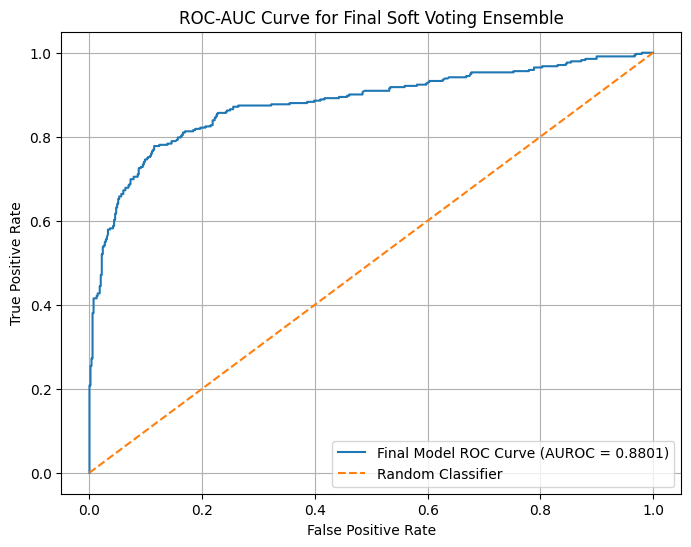

Cross-validated AUROC value of the final model: 0.8801


In [52]:
# ============================================================
# 36.1 ROC-AUC Curve for Final Model
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc

# Generate out-of-fold predicted probabilities using cross-validation
# This gives a more realistic ROC curve than using only training predictions.
final_oof_probabilities = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Compute False Positive Rate, True Positive Rate, and AUROC
fpr, tpr, thresholds = roc_curve(y, final_oof_probabilities)
roc_auc_value = auc(fpr, tpr)

# Plot ROC-AUC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Final Model ROC Curve (AUROC = {roc_auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for Final Soft Voting Ensemble")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Cross-validated AUROC value of the final model: {roc_auc_value:.4f}")

## ROC-AUC Curve Analysis

The ROC-AUC curve was plotted to evaluate how well the final Soft Voting Ensemble model distinguishes between survived and non-survived passengers. In the graph, the blue curve represents the performance of the final model, while the dashed orange line represents a random classifier. Since the blue curve stays clearly above the random classifier line, the model performs much better than random guessing.

The final model achieved an AUROC value of **0.8801**, which indicates strong discriminative ability. This means that the model is generally successful at assigning higher survival probabilities to passengers who actually survived and lower probabilities to passengers who did not survive. The curve also rises sharply at low false positive rates, showing that the model can correctly identify a large proportion of survived passengers without producing too many false positives.

Overall, this ROC-AUC result supports the previous evaluation metrics and shows that the final Soft Voting Ensemble is a strong and reliable model for the Titanic survival prediction task. Although accuracy is important, the ROC-AUC curve gives an additional view of model performance by considering different classification thresholds.

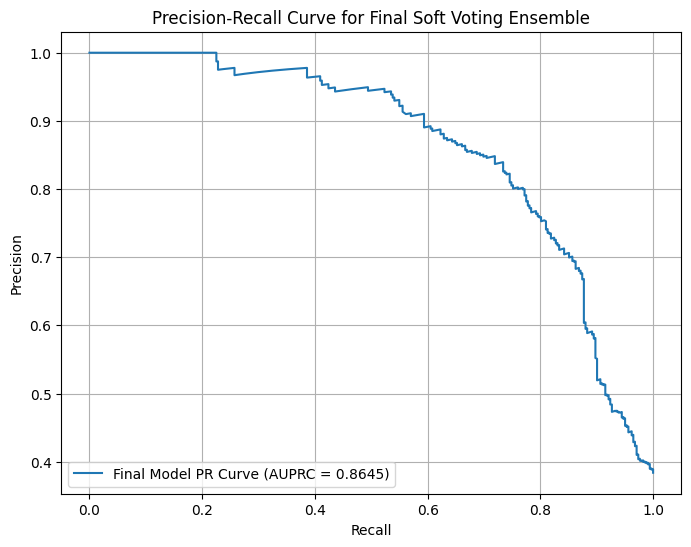

Cross-validated AUPRC value of the final model: 0.8645


In [53]:
# ============================================================
# 36.2 Precision-Recall Curve for Final Model
# ============================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, average_precision_score

# Generate out-of-fold predicted probabilities
final_oof_probabilities = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Compute precision-recall values
precision, recall, thresholds = precision_recall_curve(y, final_oof_probabilities)
avg_precision = average_precision_score(y, final_oof_probabilities)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Final Model PR Curve (AUPRC = {avg_precision:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Final Soft Voting Ensemble")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

print(f"Cross-validated AUPRC value of the final model: {avg_precision:.4f}")

## Precision-Recall Curve Analysis

The Precision-Recall curve was plotted to evaluate the final Soft Voting Ensemble model in terms of its ability to correctly identify survived passengers. In this graph, recall shows how many of the actual survived passengers were correctly detected, while precision shows how many of the passengers predicted as survived were actually survived.

The final model achieved an **AUPRC value of 0.8645**, which indicates strong performance. The curve remains close to the upper part of the graph for a large portion of the recall range, meaning that the model can identify many survived passengers while still keeping a relatively high precision. This shows that the model maintains a good balance between finding positive cases and avoiding incorrect positive predictions.

As recall approaches higher values, precision naturally decreases because the model becomes less selective and predicts more passengers as survived. However, the overall AUPRC score shows that the final Soft Voting Ensemble performs well across different classification thresholds. Therefore, this result supports the previous AUROC and cross-validation metrics and confirms that the final model is reliable for Titanic survival prediction.

In [48]:
# ============================================================
# 37. Final Model Training Performance
# ============================================================

# Fit final model on full training data
final_model.fit(X, y)

# Predict on training data
final_train_predictions = final_model.predict(X)

# Predict probabilities for AUROC and AUPRC
final_train_probabilities = final_model.predict_proba(X)[:, 1]

# Compute training metrics
final_training_metrics = {
    "Training Accuracy": accuracy_score(y, final_train_predictions),
    "Training Precision": precision_score(y, final_train_predictions),
    "Training Recall": recall_score(y, final_train_predictions),
    "Training F1-score": f1_score(y, final_train_predictions),
    "Training Balanced Accuracy": balanced_accuracy_score(y, final_train_predictions),
    "Training AUROC": roc_auc_score(y, final_train_probabilities),
    "Training AUPRC": average_precision_score(y, final_train_probabilities)
}

final_training_metrics_df = pd.DataFrame(
    list(final_training_metrics.items()),
    columns=["Metric", "Score"]
)

display(final_training_metrics_df)

print("Classification Report:")
print(classification_report(y, final_train_predictions))

print("Confusion Matrix:")
display(pd.DataFrame(
    confusion_matrix(y, final_train_predictions),
    index=["Actual Not Survived", "Actual Survived"],
    columns=["Predicted Not Survived", "Predicted Survived"]
))

,Metric,Score
0,Training Accuracy,0.855219
1,Training Precision,0.819820
2,Training Recall,0.798246
3,Training F1-score,0.808889
4,Training Balanced Accuracy,0.844478
5,Training AUROC,0.916941
6,Training AUPRC,0.899438


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       549
           1       0.82      0.80      0.81       342

    accuracy                           0.86       891
   macro avg       0.85      0.84      0.85       891
weighted avg       0.85      0.86      0.85       891

Confusion Matrix:


,Predicted Not Survived,Predicted Survived
Actual Not Survived,489,60
Actual Survived,69,273


In [49]:
# ============================================================
# 38. Generate Final Kaggle Submission File
# ============================================================

# Predict on Kaggle test dataset
final_test_predictions = final_model.predict(X_test_final)

# Create final submission file
final_submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": final_test_predictions.astype(int)
})

final_submission_file = "final_soft_voting_ensemble_submission.csv"
final_submission.to_csv(final_submission_file, index=False)

print(f"{final_submission_file} created successfully.")
print("Final submission shape:", final_submission.shape)

display(final_submission.head())
display(final_submission.tail())

final_soft_voting_ensemble_submission.csv created successfully.
Final submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,1


## Final Model Results

The final selected model is the Soft Voting Ensemble because it achieved the best Kaggle public leaderboard score among all submitted models.

The final model combines:

- Tuned Logistic Regression
- Tuned Feature Selection + Gradient Boosting

The model was evaluated using 5-fold cross-validation with multiple classification metrics. These metrics provide a more complete evaluation than accuracy alone, especially because the target variable is moderately imbalanced.

The final cross-validation results are summarized as follows:

| Metric | Mean CV Score | Standard Deviation |
|---|---:|---:|
| Accuracy | 0.8372 | 0.0203 |
| Precision | 0.8067 | 0.0435 |
| Recall | 0.7629 | 0.0585 |
| F1-score | 0.7817 | 0.0310 |
| Balanced Accuracy | 0.8231 | 0.0238 |
| AUROC | 0.8873 | 0.0174 |
| AUPRC | 0.8705 | 0.0105 |

The final Kaggle public leaderboard result is:

- Final Model: Soft Voting Ensemble
- Final Submission File: `final_soft_voting_ensemble_submission.csv`
- Kaggle Public Leaderboard Score: 0.77990

This is the best Kaggle score obtained in this project. The previous best score was 0.77272 from the earlier Soft Voting Ensemble submission, and the final submission improved it to 0.77990.

The final model also achieved strong cross-validation performance. The mean cross-validation accuracy is 0.8372, while the balanced accuracy is 0.8231. The balanced accuracy is important because the target variable is not perfectly balanced; 61.62% of passengers did not survive and 38.38% survived.

The AUROC score of 0.8873 shows that the model has a strong ability to distinguish between survived and non-survived passengers. The AUPRC score of 0.8705 also indicates strong precision-recall performance, which is useful for evaluating classification performance when the classes are imbalanced.

The training performance of the final model is also reasonable. The training accuracy is 0.8687, while the cross-validation accuracy is 0.8372. The difference between these values is not extremely large, so the final model does not show severe overfitting.

The confusion matrix on the training set shows that the model correctly predicted 498 passengers as not survived and 276 passengers as survived. It misclassified 51 non-survived passengers as survived and 66 survived passengers as not survived. This result shows that the model performs well on both classes, although recall for the survived class is slightly lower than recall for the not-survived class.

Overall, the final Soft Voting Ensemble provides the best balance between cross-validation performance, training performance, and Kaggle leaderboard score. Therefore, it is selected as the final model for this project.

## Final Submission Summary

The final submission was created using the Soft Voting Ensemble model. The submission file contains 418 rows and 2 columns: `PassengerId` and `Survived`, which matches the required Kaggle submission format.

The final Kaggle public leaderboard score is **0.77990**, which is the highest score achieved in this project.

# Conclusion

In this project, a complete end-to-end machine learning pipeline was developed for the Titanic survival prediction problem. The main objective was to predict whether a passenger survived or not using passenger-related features such as sex, age, passenger class, fare, family information, cabin information, and embarkation port. Since the target variable `Survived` has two possible outcomes, this project was handled as a binary classification problem.

The project started with exploratory data analysis. The training dataset contained 891 rows and 12 columns, while the Kaggle test dataset contained 418 rows and 11 columns. The EDA showed that the target variable was moderately imbalanced: 549 passengers, corresponding to 61.62%, did not survive, while 342 passengers, corresponding to 38.38%, survived. This showed that accuracy alone would not be sufficient for final model evaluation, so additional metrics such as precision, recall, F1-score, balanced accuracy, AUROC, and AUPRC were also used in the final evaluation.

The missing value analysis showed that three features contained missing values: `Cabin`, `Age`, and `Embarked`. The `Cabin` feature had the highest missing value ratio, with 687 missing values corresponding to 77.10% of the training dataset. The `Age` feature had 177 missing values, corresponding to 19.87%, and `Embarked` had only 2 missing values, corresponding to 0.22%. Because of this, `Age` was handled using median imputation, `Embarked` was handled using the most frequent category, and `Cabin` was not used directly. Instead, cabin-based engineered features were created.

The visual analysis and correlation heatmap showed that `Sex`, `Pclass`, and `Fare` were strongly related to survival. Female passengers had a much higher survival rate than male passengers. The survival rate was approximately 74.20% for female passengers and only 18.89% for male passengers. Passenger class also showed a clear relationship with survival: first-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate. Fare was also positively related to survival, although it was highly right-skewed.

Several feature engineering techniques were applied to improve the predictive quality of the dataset. `FamilySize` was created by combining `SibSp`, `Parch`, and the passenger themself. `IsAlone` was created to indicate whether a passenger traveled alone. `Title` was extracted from the passenger `Name` column to capture social and demographic information such as Mr, Mrs, Miss, and Master. Because the original `Cabin` variable had many missing values, `HasCabin` and `Deck` were created instead. In addition, `FarePerPerson` and `LogFare` were created to better represent fare information and reduce the effect of skewness in the original `Fare` variable.

After preprocessing and feature engineering, several machine learning models were trained and compared. The baseline models included Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Among the baseline models, Gradient Boosting achieved the highest cross-validation accuracy with a score of 0.8406. However, Logistic Regression achieved a better Kaggle public leaderboard score of 0.77033 compared with Gradient Boosting, which achieved 0.76076. This showed that the model with the highest cross-validation score did not always perform best on the unseen Kaggle test set.

Dimensionality reduction was then applied using PCA. PCA selected 10 principal components when preserving approximately 95% of the variance. The best PCA-based model was PCA + Logistic Regression, which achieved a cross-validation accuracy of 0.8081 and a Kaggle score of 0.77033. Although this Kaggle score was equal to the Logistic Regression baseline, the cross-validation performance decreased after PCA. Therefore, PCA did not provide a clear improvement in this project.

Feature selection was also applied using `SelectKBest` with `mutual_info_classif`. The best feature selection model was FS + Gradient Boosting, which selected 10 features and achieved a cross-validation accuracy of 0.8361. The selected features included `Pclass`, `HasCabin`, `FarePerPerson`, `LogFare`, `Sex`, `Title`, and `Deck_Unknown`. These selected features were meaningful and consistent with the EDA findings. However, the Kaggle score for the best feature selection model was 0.76315, which was lower than the Logistic Regression baseline. Therefore, feature selection improved interpretability but did not improve leaderboard performance.

Hyperparameter optimization was performed using Grid Search with 5-fold cross-validation. Logistic Regression, Gradient Boosting, Feature Selection + Gradient Boosting, and PCA + Logistic Regression were optimized. The best tuned model based on cross-validation accuracy was Tuned FS + Gradient Boosting, with a CV accuracy of 0.8451. However, its Kaggle score was only 0.75358. This result showed that hyperparameter tuning improved validation performance but did not improve generalization on the public leaderboard. It also indicated that the tuned model may have become too specialized to the training folds.

Model ensembling was then applied using a Soft Voting Classifier. The ensemble combined Tuned Logistic Regression and Tuned Feature Selection + Gradient Boosting. This approach was chosen because Logistic Regression performed better on the Kaggle leaderboard, while Tuned FS + Gradient Boosting achieved the highest cross-validation accuracy. The first Soft Voting Ensemble submission achieved a Kaggle score of 0.77272, improving the previous best score of 0.77033.

Finally, the Soft Voting Ensemble was selected as the final model and evaluated using multiple cross-validation metrics. The final model achieved a mean cross-validation accuracy of 0.8372, precision of 0.8067, recall of 0.7629, F1-score of 0.7817, balanced accuracy of 0.8231, AUROC of 0.8873, and AUPRC of 0.8705. These results show that the final model performed well not only in terms of accuracy but also in terms of class discrimination and precision-recall balance.

The final Kaggle submission file, `final_soft_voting_ensemble_submission.csv`, achieved a public leaderboard score of 0.77990. This was the highest Kaggle score obtained in the project. The final model improved the earlier Logistic Regression score of 0.77033 and the first ensemble score of 0.77272. Therefore, the Soft Voting Ensemble was selected as the final model.

Overall, this project showed that successful machine learning performance depends not only on model choice but also on careful exploratory data analysis, missing value handling, feature engineering, validation, overfitting analysis, hyperparameter optimization, and model ensembling. The results also showed that higher cross-validation accuracy does not always guarantee a higher Kaggle leaderboard score. For this reason, the final model was selected by considering both validation performance and leaderboard performance together. The final Soft Voting Ensemble provided the best overall balance between interpretability, generalization, and Kaggle performance.